# Google map review star-rating classifier

*   Ahmed Nashwan Abdulkarem Al-Ansi
*   Alan Tan Yong Hong
*   Chia Zheng Rong
*   Chong Shing Boa

# Introduction

The objective of this project is to develop a multi-class text classification model that is capable of predicting user-provided ratings based on unseen text reviews. The dataset provided is derived from Google Maps user reviews, where services are rated on a scale from 1-star rating (low) to 5-star rating (maximum). A modified version of the dataset was provided, which explicitly includes only the review text and their corresponding star rating, with all other user metadata removed.


# Mounting Drive

Connecting Google Colab notebook to drive to access datasets.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Navigate to the correct directory
%cd /content/drive/MyDrive/F20AA - Coursework datasets/Coursework 2/

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1UDxVJBab-IBfTtVmoZr15F0yrlRH7iiY/F20AA - Coursework datasets/Coursework 2


# Data Exploration and Visualization

## **1.1 Dataset Overview & Target Class Distribution**
The provided training dataset consists of raw text reviews and their corresponding discrete target ratings on a scale of 1 to 5. Initial inspection of the target variable reveals a distinctly non-uniform class distribution. The target classes for this classification problem are the user-provided ratings {1, 2, 3, 4, 5}. Before training any models, we must investigate the distribution of these classes. Real-world review datasets often suffer from class imbalance, which can bias a model toward predicting the majority class. Our initial assumption is that we will see a polarity bias (a high number of 1-star and 5-star reviews). We will plot a frequency distribution to confirm this, which will directly inform our choice of evaluation metrics later.

/tmp/ipykernel_427/1659987307.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=train_df, x='rating', palette='viridis')


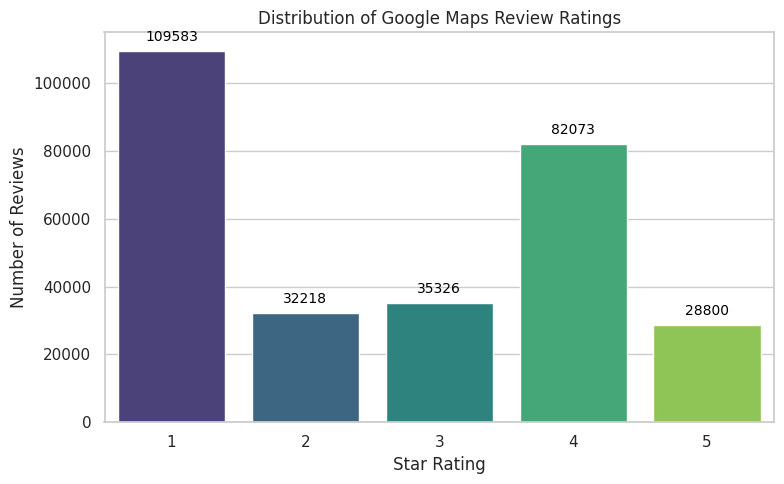

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for the report
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

train_df = pd.read_csv('train.csv')

# 1.1 Target Class Distribution
# To understand the baseline polarity of our Google Maps reviews, we first analyze the distribution of the target variable (ratings 1 through 5).

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train_df, x='rating', palette='viridis')
plt.title('Distribution of Google Maps Review Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')

# Add exact counts on top of the bars for the report
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.savefig('initial_star_rating_class_distribution.png', dpi=300)
plt.show()

**Initial Analysis & Assumption Conclusion**

Contrary to a standard polarity bias, the plot reveals a heavy skew towards 4-star and 1-star rating, with 2, 3, and 5-star categories significantly underrepresented. Because the classes are highly imbalanced, using standard Accuracy to compare our models will be misleading. Moving forward, we must use a Macro-Averaged or Weighted F1-score to ensure fair inter-model comparison. Next, we will analyze the text length to prepare our data for sequence-based models.

## **1.2 Sequence Length Analysis**
Our experimental setup requires comparing classical Bag-of-Words (BoW) models against sequence-dependent architectures (LSTM, Transformers), analyzing the token length of the reviews is a critical EDA step. We calculated the word count for each review and plotted the sequence length distribution as a histogram.

*   **Implication for Naive Bayes:** The BoW approach is largely agnostic to sequence length, processing reviews purely as sparse frequency matrices.

*   **Implication for Deep Learning:** Sequence models have fixed context windows and suffer from computational overhead or vanishing gradients on excessively long sequences. By identifying the 85th percentile of sequence lengths in our EDA, we can establish an optimal truncation and padding threshold that minimizes information loss while maximizing training efficiency.

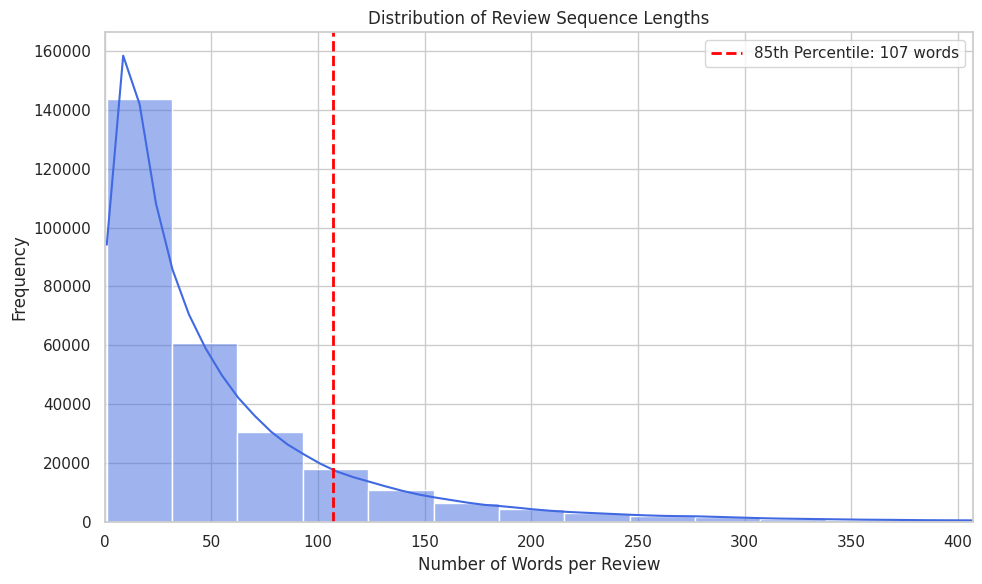

In [ ]:
# 1.2 Sequence Length Analysis
# Before passing text into sequence-dependent models (LSTMs/Transformers),
# we determine the distribution of review lengths to establish an optimal max_length.

# Calculate word count for each review by splitting on whitespace
train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(train_df['word_count'], bins=50, kde=True, color='royalblue')

# Calculate and plot the 95th percentile to justify max_len choice
percentile_85 = train_df['word_count'].quantile(0.85)
plt.axvline(percentile_85, color='red', linestyle='dashed', linewidth=2,
            label=f'85th Percentile: {int(percentile_85)} words')

plt.title('Distribution of Review Sequence Lengths')
plt.xlabel('Number of Words per Review')
plt.ylabel('Frequency')
plt.xlim(0, train_df['word_count'].quantile(0.99)) # Cut off extreme outliers
plt.legend()

plt.tight_layout()
plt.savefig('initial_sequence_length_analysis.png', dpi=300)
plt.show()

**Initial Sequence Length Analysis Conclusion**

The histogram shows a highly right-skewed distribution, confirming that most reviews are relatively brief. The **85th percentile sits at 107 words**. Based on this finding, we can confidently set a `max_length` parameter of roughly 128 tokens for our LSTM and Transformer models. This threshold will capture the full semantic context for 85% of the dataset while preventing unnecessary padding and wasted computational resources. Next up, we explore lexical analysis and N-gram exploration.

## **1.3 Lexical Analysis & N-Gram Exploration**
To understand the baseline semantic signals in the dataset, we extracted the top frequent unigrams and bigrams for the extreme classes (1-star versus 5-star) using a standard stop-word filtered pipeline. Word clouds and frequency bar charts for these n-grams show distinct lexical groupings. We assume that while unigrams will show obvious sentiment words (e.g., "bad", "great"), bigrams and trigrams will reveal critical contextual phrases (e.g., "never returning", "highly recommend", "bad customer services", "amazing food place") that simple unigram models miss.

We will examine the five-star reviews and the one-star reviews separately to visualize these lexical differences.

/tmp/ipykernel_427/149164077.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], x=[val[1] for val in top_unigrams_1], y=[val[0] for val in top_unigrams_1], palette='Reds_r')
/tmp/ipykernel_427/149164077.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x=[val[1] for val in top_unigrams_5], y=[val[0] for val in top_unigrams_5], palette='Greens_r')
/tmp/ipykernel_427/149164077.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0], x=[val[1] for val in top_bigrams_1], y=[val[0] for val in top_bigr

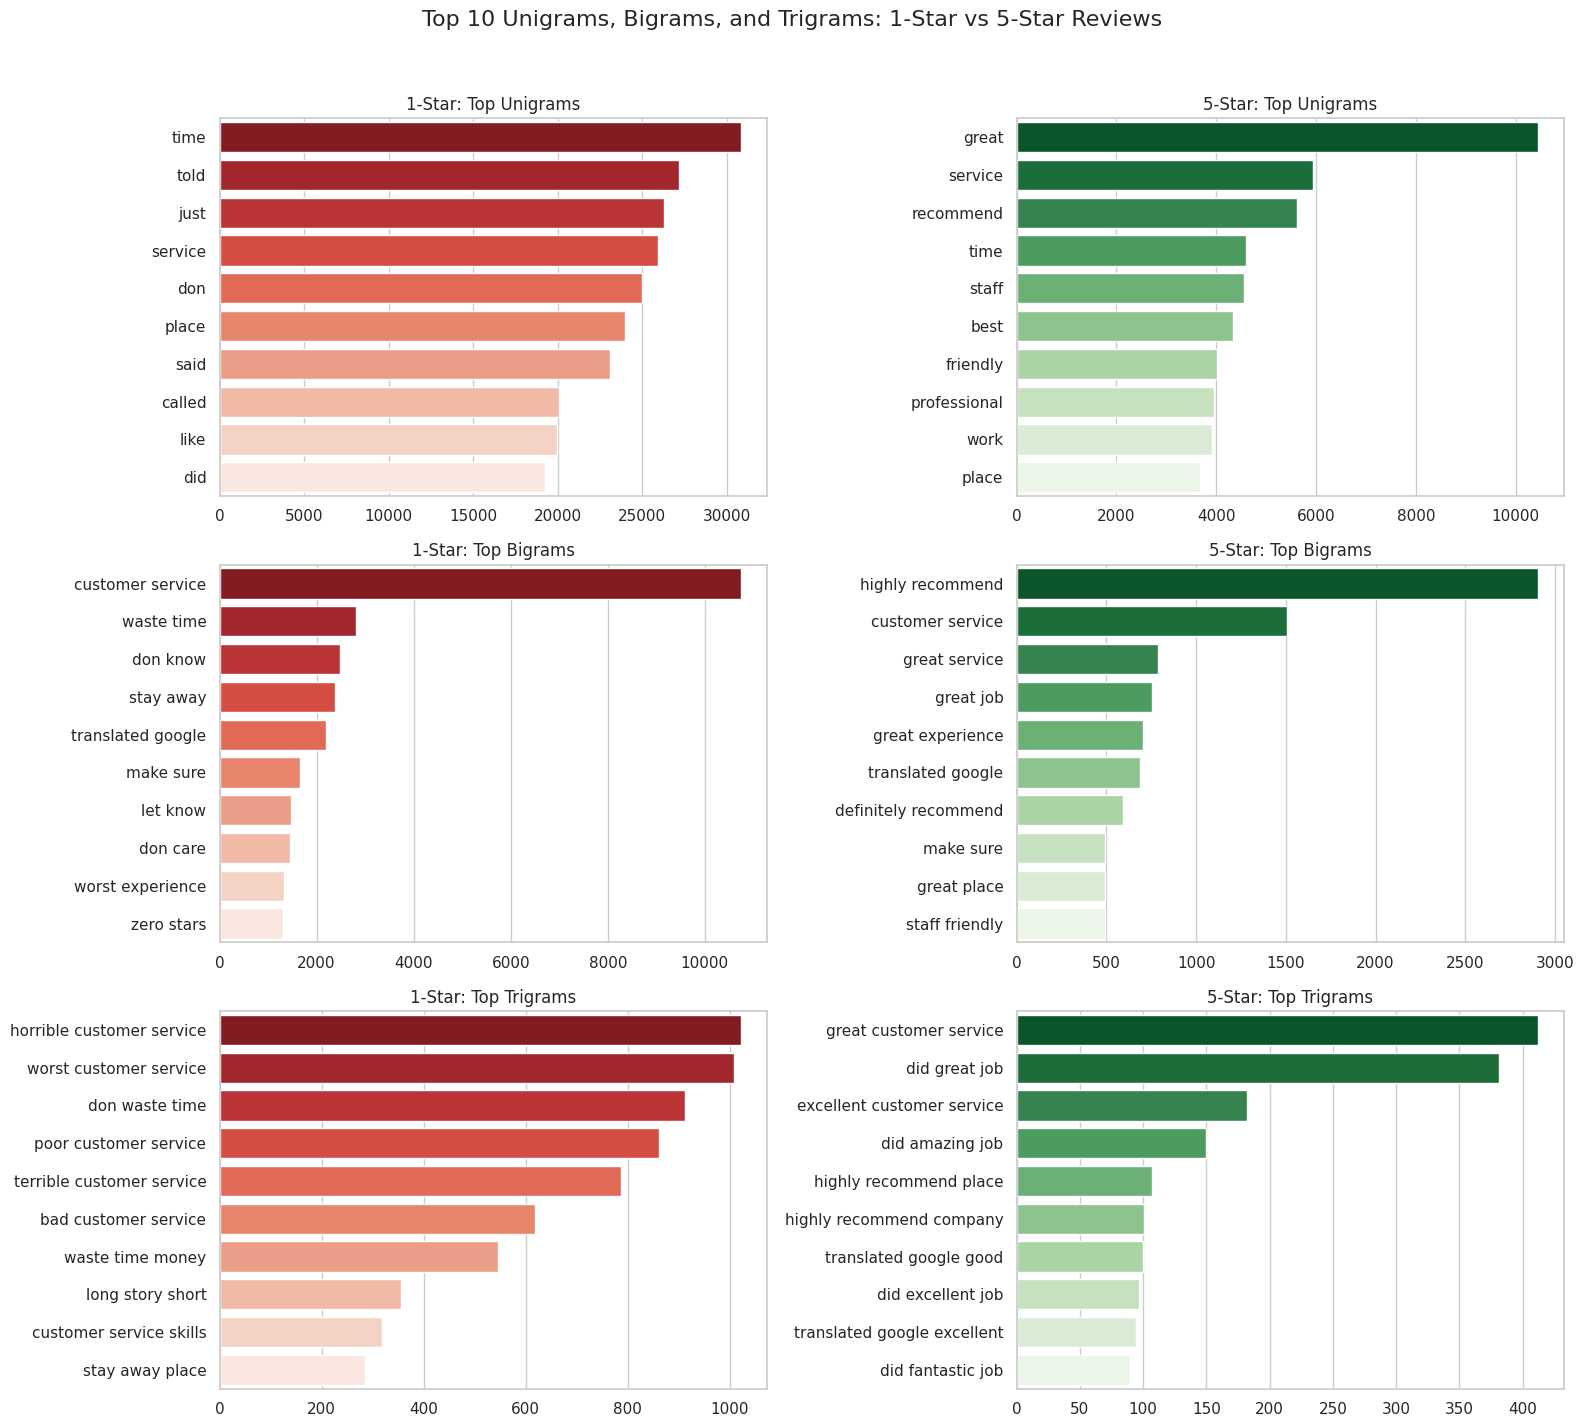

In [ ]:
# 1.3 Lexical Analysis & N-Gram Exploration (Unigrams, Bigrams, Trigrams)
from sklearn.feature_extraction.text import CountVectorizer

# Filter for the extreme classes
reviews_1star = train_df[train_df['rating'] == 1]['text'].astype(str)
reviews_5star = train_df[train_df['rating'] == 5]['text'].astype(str)

# Helper function to extract top n-grams
def get_top_ngrams(corpus, ngram_range=(1, 1), n=10):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Extract unigrams, bigrams, and trigrams
top_unigrams_1 = get_top_ngrams(reviews_1star, ngram_range=(1, 1), n=10)
top_unigrams_5 = get_top_ngrams(reviews_5star, ngram_range=(1, 1), n=10)

top_bigrams_1 = get_top_ngrams(reviews_1star, ngram_range=(2, 2), n=10)
top_bigrams_5 = get_top_ngrams(reviews_5star, ngram_range=(2, 2), n=10)

top_trigrams_1 = get_top_ngrams(reviews_1star, ngram_range=(3, 3), n=10)
top_trigrams_5 = get_top_ngrams(reviews_5star, ngram_range=(3, 3), n=10)

# Plotting the results (3x2 grid)
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.suptitle('Top 10 Unigrams, Bigrams, and Trigrams: 1-Star vs 5-Star Reviews', fontsize=16)

# Unigrams
sns.barplot(ax=axes[0, 0], x=[val[1] for val in top_unigrams_1], y=[val[0] for val in top_unigrams_1], palette='Reds_r')
axes[0, 0].set_title('1-Star: Top Unigrams')

sns.barplot(ax=axes[0, 1], x=[val[1] for val in top_unigrams_5], y=[val[0] for val in top_unigrams_5], palette='Greens_r')
axes[0, 1].set_title('5-Star: Top Unigrams')

# Bigrams
sns.barplot(ax=axes[1, 0], x=[val[1] for val in top_bigrams_1], y=[val[0] for val in top_bigrams_1], palette='Reds_r')
axes[1, 0].set_title('1-Star: Top Bigrams')

sns.barplot(ax=axes[1, 1], x=[val[1] for val in top_bigrams_5], y=[val[0] for val in top_bigrams_5], palette='Greens_r')
axes[1, 1].set_title('5-Star: Top Bigrams')

# Trigrams
sns.barplot(ax=axes[2, 0], x=[val[1] for val in top_trigrams_1], y=[val[0] for val in top_trigrams_1], palette='Reds_r')
axes[2, 0].set_title('1-Star: Top Trigrams')

sns.barplot(ax=axes[2, 1], x=[val[1] for val in top_trigrams_5], y=[val[0] for val in top_trigrams_5], palette='Greens_r')
axes[2, 1].set_title('5-Star: Top Trigrams')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('initial_lexical_and_ngram_exploration_extended.png', dpi=300)
plt.show()

**Initial Lexical Analysis & N-Gram Exploration Conclusion**

The expanded bar charts confirm our initial assumption and provide a deeper layer of insight into user behaviors. Relying solely on unigrams provides an incomplete picture; 1-star unigrams feature generic terms like "time" or "place," which lack inherent negative sentiment.

However, higher-order n-grams successfully capture the critical semantic meaning present in word ordering. The 1-star bigrams and trigrams explicitly reveal the primary drivers of negative ratings: excessive wait times and definitive negative actions ("waste time", "horrible customer service"). Conversely, 5-star trigrams capture complete compound endorsements ("highly recommend place", "great customer service").

This visually justifies our overarching modeling strategy: while Naive Bayes will serve as a baseline relying on isolated token frequencies, sequence models (LSTM/Transformers) are necessary to natively understand the extended contextual ordering that drives real-world reviews.

## **1.4 Performance Metrics for Inter-Models Comparison**
Relying on standard Accuracy for a heavily imbalanced, multi-class dataset introduces the Accuracy Paradox, where models achieve artificially high scores by simply predicting the majority class. To ensure a fair and rigorous comparison across the Naive Bayes, LSTM, and Transformer architectures, we have established the following evaluation metrics:


*   **Weighted F1-Score (Primary Metric)**: This balances Precision and Recall while strictly accounting for the support (number of true instances) of each class, ensuring that minority classes are fairly represented in the final score.

*   **PR-AUC**: Because our classes are highly imbalanced, PR-AUC provides a more reliable performance measure than standard ROC-AUC. It evaluates the model's ability to maintain high precision as recall increases, specifically highlighting how well the model handles the underrepresented classes without generating false positives.

*   **Balanced Accuracy**: This metric calculates the arithmetic mean of sensitivity (recall) for each class independently. It effectively normalizes the varying class supports, preventing the majority classes from dominating the overall performance score and exposing models that fail to learn the minority class distributions..

# Text Preprocessing and Normalisation

## Text Preprocessing for Naive Bayes and LSTM
To build an effective categorization system, text data must be mathematically represented. However, different machine learning architectures process language fundamentally differently. Probabilistic models like Naive Bayes rely on word-frequency counts (Bag-of-Words), while deep learning models like LSTMs rely on word ordering and grammatical context to derive semantic meaning.

Therefore, a single preprocessing pipeline is insufficient. To thoroughly experiment with different text processing and normalization alternatives, this sub-section designs three distinct preprocessing pipelines.

### Imports and Initialisation
First, we initialize our NLP tools. A critical step here is the customization of the NLTK stopword list. Standard stopword removal blindly deletes negative markers (e.g., "not", "no", "won't"). In sentiment analysis, removing these words flips the sentiment of the text (e.g., "not happy" becomes "happy"). We explicitly whitelist these negative markers to preserve the core sentiment.

In [ ]:
import pandas as pd
import re
import string
import nltk
import unicodedata
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

# Customize stopwords critical for sentiment
stop_words = set(stopwords.words('english'))

# Remove negatives from stop words so we don't break sentiment (e.g. "not happy" -> "happy")
negatives = {
    # Core negatives
    "no", "not", "nor", "neither", "none", "never",

    # Absolute/Contextual negatives
    "nothing", "nowhere", "cannot", "without",

    # Semi-negatives
    "hardly", "barely", "scarcely", "rarely", "seldom",

    # Safety Net (Proper apostrophes)
    "don't", "can't", "won't", "isn't", "aren't", "wasn't", "weren't",
    "hasn't", "haven't", "hadn't", "doesn't", "didn't", "wouldn't", "shouldn't", "couldn't"

    # Lazy internet typing (Missing apostrophes)
    "dont", "cant", "wont", "isnt", "arent", "wasnt", "werent",
    "hasnt", "havent", "hadnt", "doesnt", "didnt", "wouldnt", "shouldnt", "couldnt"
}
stop_words = stop_words - negatives

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


### Defining the Experimental Pipelines
To evaluate the trade-offs of different text preprocessing techniques, we establish three progressive text preprocessing pipelines:

1. **Pipeline 1: Minimal (Sequence Preservation):** Ideal for LSTM. It standardises casing and fixes Unicode artifacts, removes unecessary emojis if present, but strictly preserves syntactic punctuation (!, ?, .) and stopwords. This maintains the sequential grammar required for word embeddings to understand context.

2. **Pipeline 2: Standard (Noise Reduction):** Designed as a baseline for Naive Bayes. It applies the Minimal pipeline and strips all punctuation and removes our customized stopwords, aggressively reducing noise that does not contribute to word-frequency probabilities.

3. **Pipeline 3: Lemmatised (Aggressive Normalisation):** Designed to optimize Naive Bayes. It applies the Standard pipeline, then uses a POS-aware lemmatizer to reduce words to their morphological roots, aiming to drastically shrink the vocabulary space and reduce matrix sparsity.

In [ ]:
def preprocess_minimal(text):
    """
    Pipeline 1: Sequence Preservation (For Deep Learning / LSTMs).
    Explicitly retains syntactic punctuation
    and stopwords to maintain the semantic context and word ordering required for
    sequence-based models and word embeddings.
    """
    # A. Lowercasing
    text = text.lower()

    # B. Unicode Normalization:(é -> e), (“ -> ")
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')

    # C. Remove URLs (http...)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # D. Remove HTML tags if any exist
    text = re.sub(r'<.*?>', '', text)

    # E. Expand contraction words
    # E1. Handle specific irregular contractions first
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"ain't", "is not", text)
    text = re.sub(r"let's", "let us", text)

    # 2. Handle general contractions
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'m", " am", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'s", " is", text)

    # F. Preserve selected alphanumeric and syntactic punctuation (Removes emojis and obscure unicode)
    text = re.sub(r"[^a-z0-9\s\.\,\!\?\"\#\$\@\%\^\&\*\(\)\-\+\=\_\'\;\:]", ' ', text)

    # G. cleanup extra spaces created by the above (e.g., "years    they" -> "years they")
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_standard(text):
    """
    Ideal for Classical Models like Naive Bayes.
    Aggressively strips all punctuation and removes stopwords to reduce feature
    matrix sparsity and eliminate noise that does not contribute to word-frequency probabilities.
    """
    # A. Inherit basic cleaning
    text = preprocess_minimal(text)

    # B. Strict alphanumeric filtering (Removes ALL punctuation)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # C. cleanup extra spaces created by the above (e.g., "years    they" -> "years they")
    text = re.sub(r'\s+', ' ', text).strip()

    # D. Remove previously Customized Stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

def preprocess_lemmatized(text):
    """
    Pipeline 3: More Aggressive Normalization (Ideal for Classical Model Optimization).
    Applies standard cleaning, then lemmatizes words to their morphological roots
    to drastically shrink the vocabulary space and improve computational efficiency.
    """
    # A. Inherit standard cleaning
    text = preprocess_standard(text)

    # B. Lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

### Applying the Pipelines
We now apply the three experimental pipelines to our training dataset, creating isolated text columns to ensure a fair, comparative baseline evaluation.

In [ ]:
# Create new columns for each experimental pipeline for comparison later
# Retrieve initial training set
df = pd.read_csv("train.csv")

print("Applying minimal cleaning...")
df['text_minimal'] = df['text'].apply(preprocess_minimal)

print("Applying standard cleaning...")
df['text_standard'] = df['text'].apply(preprocess_standard)

print("Applying lemmatization...")
df['text_lemmatized'] = df['text'].apply(preprocess_lemmatized)

# Display the differences
df[['text', 'text_minimal', 'text_standard', 'text_lemmatized']].head()

Applying minimal cleaning...
Applying standard cleaning...
Applying lemmatization...


,text,text_minimal,text_standard,text_lemmatized
0,This place is TERRIBLE; the people in charge a...,this place is terrible; the people in charge a...,place terrible people charge worst part far ye...,place terrible people charge worst part far ye...
1,Terrible Service! And they are saying that I n...,terrible service! and they are saying that i n...,terrible service saying never used service lie...,terrible service saying never used service lie...
2,Absolutely terrible company. They sent me to ...,absolutely terrible company. they sent me to c...,absolutely terrible company sent collections w...,absolutely terrible company sent collection wi...
3,"To find it, either park in front of the Tuesda...","to find it, either park in front of the tuesda...",find either park front tuesday morning mall en...,find either park front tuesday morning mall en...
4,Mall location. Used their services for sedan. ...,mall location. used their services for sedan. ...,mall location used services sedan nice perhaps...,mall location used service sedan nice perhaps ...


### Text Preprocessing Pipeline Evaluation
The Google Maps review dataset is heavily imbalanced, with a strong bias toward 1-star and 4-star ratings. Using standard Accuracy as an evaluation metric in this context leads to the Accuracy Paradox, where a model can score highly simply by over-predicting the majority classes. To ensure our text preprocessing pipelines are evaluated fairly across all ratings, we utilise the Weighted F1-Score, which balances Precision and Recall while accounting for class support.

#### Text Preprocessing Pipeline Evaluation: Naive Bayes
To determine the optimal level of text preprocessing and normalisation for classical Bag-of-Words models (Naive Bayes), we evaluate the three text preprocessing pipelines against a baseline Multinomial Naive Bayes classifier. The model utilizes a full-vocabulary TF-IDF vectorization (filtering out extreme outliers with `min_df=2`) to accurately measure how each preprocessing strategy impacts matrix sparsity and word-frequency probabilities.

/tmp/ipykernel_1829/1527010703.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')


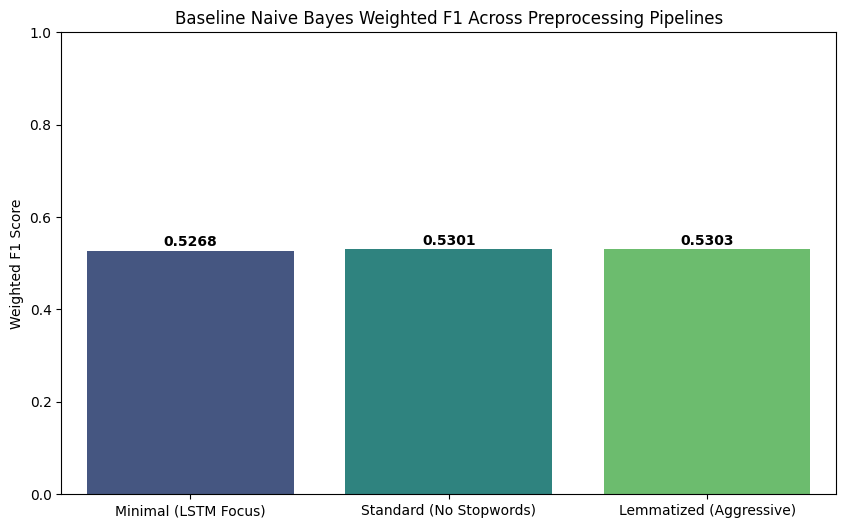

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_pipeline(df, text_column, target_column='rating'):
    """Trains a full-vocabulary Naive Bayes baseline to test the text preprocessing pipeline."""
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        df[text_column], df[target_column], test_size=0.2, random_state=37
    )

    # TF-IDF Vectorization
    vectorizer = TfidfVectorizer(min_df=2)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    # Train and predict
    model = MultinomialNB(alpha=0.5)
    model.fit(X_train_vec, y_train)
    predictions = model.predict(X_test_vec)

    return f1_score(y_test, predictions, average='weighted')

# Run the evaluation
results = {
    'Minimal (LSTM Focus)': evaluate_pipeline(df, 'text_minimal'),
    'Standard (No Stopwords)': evaluate_pipeline(df, 'text_standard'),
    'Lemmatized (Aggressive)': evaluate_pipeline(df, 'text_lemmatized')
}

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title('Baseline Naive Bayes Weighted F1 Across Preprocessing Pipelines')
plt.ylabel('Weighted F1 Score')
plt.ylim(0, 1.0) # Adjust based on your actual results
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

**Evaluation Results & Justification:**

As shown in the above evaluation, the Lemmatised text preprocessing pipeline yielded the highest performance for the Naive Bayes model. Naive Bayes relies on calculating probabilities based on independent word frequencies. The aggressive normalisation of the lemmatised pipeline effectively reduced matrix sparsity by collapsing varying word forms (e.g., "running" and "ran") into single features. While the performance gain over the Standard pipeline is slight, likely because aggressive lemmatisation occasionally strips the subtle intensity from adjectives needed to differentiate adjacent classes (e.g., 4 vs. 5 stars), the significant reduction in the vocabulary feature space makes it the optimal choice for classical Bag-of-Words modeling.

#### Text Preprocessing Pipeline Evaluation: LSTM
To compare the effect of normalization on models that treat text as a sequence, we evaluate the text preprocessing pipelines against a baseline LSTM. The neural network is trained using Early Stopping to find the true performance peak of each text representation.

Evaluating LSTM on text_minimal...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 601s 415ms/step - accuracy: 0.4676 - loss: 1.3077 - val_accuracy: 0.6178 - val_loss: 0.9658
Epoch 2/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 605s 420ms/step - accuracy: 0.6375 - loss: 0.9097 - val_accuracy: 0.6586 - val_loss: 0.8617
Epoch 3/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 598s 415ms/step - accuracy: 0.6706 - loss: 0.8219 - val_accuracy: 0.6670 - val_loss: 0.8353
Epoch 4/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 611s 424ms/step - accuracy: 0.6879 - loss: 0.7804 - val_accuracy: 0.6708 - val_loss: 0.8334
Epoch 5/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 638s 443ms/step - accuracy: 0.7024 - loss: 0.7465 - val_accuracy: 0.6669 - val_loss: 0.8472
Epoch 6/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 621s 432ms/step - accuracy: 0.7173 - loss: 0.7146 - val_accuracy: 0.6643 - val_loss: 0.8602
Evaluating LSTM on text_standard...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 837s 579ms/step - accuracy: 0.3791 - loss: 1.4616 - val_accuracy: 0.3806 - val_loss: 1.4538
Epoch 2/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 586s 407ms/step - accuracy: 0.3803 - loss: 1.4566 - val_accuracy: 0.3806 - val_loss: 1.4540
Epoch 3/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 589s 409ms/step - accuracy: 0.5236 - loss: 1.1695 - val_accuracy: 0.6434 - val_loss: 0.9045
Epoch 4/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 576s 400ms/step - accuracy: 0.6548 - loss: 0.8694 - val_accuracy: 0.6536 - val_loss: 0.8815
Epoch 5/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 587s 407ms/step - accuracy: 0.6768 - loss: 0.8104 - val_accuracy: 0.6521 - val_loss: 0.8875
Epoch 6/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 618s 404ms/step - accuracy: 0.6944 - loss: 0.7664 - val_accuracy: 0.6500 - val_loss: 0.9034
Evaluating LSTM on text_lemmatized...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 596s 412ms/step - accuracy: 0.3783 - loss: 1.4641 - val_accuracy: 0.3806 - val_loss: 1.4569
Epoch 2/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 596s 414ms/step - accuracy: 0.5877 - loss: 1.0484 - val_accuracy: 0.6446 - val_loss: 0.8969
Epoch 3/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 605s 420ms/step - accuracy: 0.6549 - loss: 0.8700 - val_accuracy: 0.6491 - val_loss: 0.8844
Epoch 4/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 598s 416ms/step - accuracy: 0.6735 - loss: 0.8180 - val_accuracy: 0.6607 - val_loss: 0.8579
Epoch 5/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 623s 416ms/step - accuracy: 0.6902 - loss: 0.7779 - val_accuracy: 0.6557 - val_loss: 0.8688
Epoch 6/10
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 595s 413ms/step - accuracy: 0.7057 - loss: 0.7417 - val_accuracy: 0.6589 - val_loss: 0.8797


/tmp/ipykernel_8551/196678579.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(lstm_results.keys()), y=list(lstm_results.values()), palette='magma')


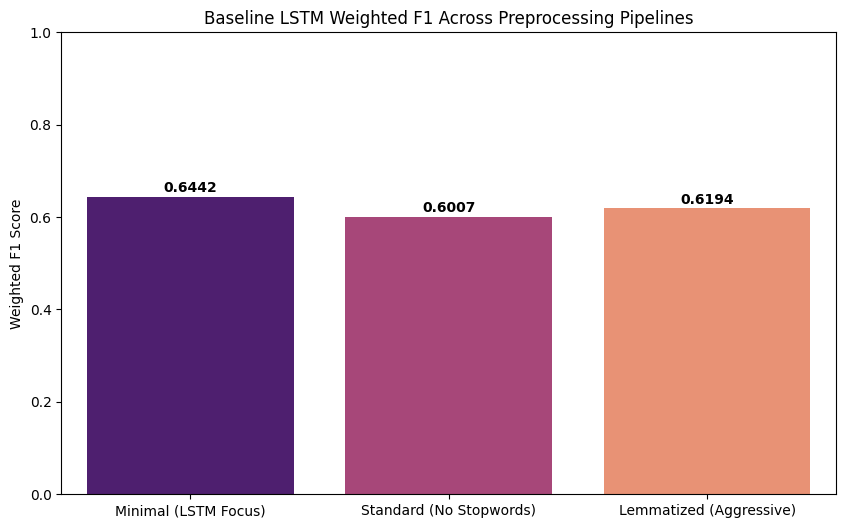

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_lstm_pipeline(df, text_column, target_column='rating'):
    """Trains a robust LSTM to fairly test the text preprocessing pipelines."""
    print(f"Evaluating LSTM on {text_column}...")

    # Encode Labels
    le = LabelEncoder()
    y = le.fit_transform(df[target_column])
    num_classes = len(np.unique(y))

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        df[text_column].astype(str), y, test_size=0.2, random_state=35
    )

    # Tokenize and Pad Sequences
    max_words = 10000  # Vocabulary size
    max_len = 200     # Standardize all reviews to 100 words long

    tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
    tokenizer.fit_on_texts(X_train)

    X_train_seq = tokenizer.texts_to_sequences(X_train)
    X_test_seq = tokenizer.texts_to_sequences(X_test)

    X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
    X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

    # Build a lightweight baseline LSTM architecture for comparison purposes
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
        LSTM(64, return_sequences=False), # Small number of units for a fast baseline test
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax') # Multi-class output
    ])

    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    # Train
    model.fit(X_train_pad, y_train,
              epochs=10,
              batch_size=128,
              validation_split=0.2,
              callbacks=[early_stop],
              verbose=1)

    # Predict probabilities, then get the highest probability class using argmax
    y_pred_probs = model.predict(X_test_pad, verbose=0)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    # Evaluate
    return f1_score(y_test, y_pred_classes, average='weighted')

# Run the evaluation for LSTM
lstm_results = {
    'Minimal (LSTM Focus)': evaluate_lstm_pipeline(df, 'text_minimal'),
    'Standard (No Stopwords)': evaluate_lstm_pipeline(df, 'text_standard'),
    'Lemmatized (Aggressive)': evaluate_lstm_pipeline(df, 'text_lemmatized')
}

# Plot the LSTM results
plt.figure(figsize=(10, 6))
sns.barplot(x=list(lstm_results.keys()), y=list(lstm_results.values()), palette='magma')
plt.title('Baseline LSTM Weighted F1 Across Preprocessing Pipelines')
plt.ylabel('Weighted F1 Score')
plt.ylim(0, 1.0) # Adjust based on your actual results
for i, v in enumerate(lstm_results.values()):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

**Evaluation Results & Justification:**

In stark contrast to the Naive Bayes results, the Minimal text preprocessing pipeline proved optimal for the LSTM. This empirically validates the theoretical requirement of deep learning sequence models (they thrive on semantic flow). By aggressively removing stopwords and punctuation, the Standard and Lemmatised text preprocessing pipelines destroyed the syntactic context and localised structure that the LSTM's embedding layer relies on to map relationships between words. Therefore, preserving the grammatical integrity of the text is paramount for sequence modeling.

#### Automated Dataset Extraction for Model Training and Testing
Based on the empirical evaluations above, this code block automatically performs the following for both the Naive Bayes and LSTM architectures:
1. **Training Set Extraction:** Identifies the winning text preprocessing pipeline for the specific architecture and extracts the already preprocessed text from our training DataFrame to create the finalised and optimally preprocessed training set for the specific architecture.
2. **Test Set Processing:** Loads the previously unseen `test.csv`, dynamically applies the specific architecture's winning text preprocessing function to it, and generates a finalised and optimally preprocessed test set for the specific architecture.

This modular approach guarantees that our naive Bayes and LSTM models are trained and tested on data mathematically optimised for their respective architectures.

In [ ]:
import os

# Map the dictionary keys to the actual DataFrame column names
column_map = {
    'Minimal (LSTM Focus)': 'text_minimal',
    'Standard (No Stopwords)': 'text_standard',
    'Lemmatized (Aggressive)': 'text_lemmatized'
}

# ==========================================================================
# Preprocess datasets using the best preprocessing pipeline for Naive Bayes
# ==========================================================================

# Find the key with the highest accuracy score
best_NB_pipeline = max(results, key=results.get)
best_NB_col = column_map[best_NB_pipeline]
best_NB_score = results[best_NB_pipeline]

print(f"\n WINNER FOR CLASSICAL MODELS (Naive Bayes): {best_NB_pipeline} ({best_NB_score:.4f})")
print(f"Extracting column '{best_NB_col}'...")

# A. TRAINING SET
# Directly extract the preprocessed text that have been preprocessed by the best preprocessing pipeline for Naive Bayes into a new DataFrame
# Create a clean subset DataFrame
df_NB_export = df[[best_NB_col, 'rating']].copy()

# Rename the winning column to a standard name
df_NB_export.rename(columns={best_NB_col: 'preprocessed_text'}, inplace=True)

# Ensure the directory exists before saving
output_dir_NB = "NB_preprocessed_datasets"
os.makedirs(output_dir_NB, exist_ok=True)

# Save to CSV
output_path_train_preprocessed_NB = os.path.join(output_dir_NB, "train_preprocessed_NB.csv")
df_NB_export.to_csv(output_path_train_preprocessed_NB, index=False)
print(f" Saved optimized preprocessed training set for Naive Bayes to: {output_path_train_preprocessed_NB}")

# B. TEST SET
# Load the initial test set
df_test = pd.read_csv("test.csv")

# Run the best preprocessing pipeline for Naive Bayes on the test set
if best_NB_pipeline == 'Minimal (LSTM Focus)':
    df_test['preprocessed_text'] = df_test['text'].apply(preprocess_minimal)
elif best_NB_pipeline == 'Standard (No Stopwords)':
    df_test['preprocessed_text'] = df_test['text'].apply(preprocess_standard)
else:
    df_test['preprocessed_text'] = df_test['text'].apply(preprocess_lemmatized)

# Create a clean subset Dataframe
df_NB_export_test = df_test[['preprocessed_text', 'rating']].copy()

# Save to CSV
output_path_test_preprocessed_NB = os.path.join(output_dir_NB, "test_preprocessed_NB.csv")
df_NB_export_test.to_csv(output_path_test_preprocessed_NB, index=False)
print(f" Saved optimized preprocessed test set for Naive Bayes to: {output_path_test_preprocessed_NB}")

# ===================================================================
# Preprocess datasets using the best preprocessing pipeline for LSTM
# ===================================================================

# Find the key with the highest accuracy score
best_LSTM_pipeline = max(lstm_results, key=lstm_results.get)
best_LSTM_col = column_map[best_LSTM_pipeline]
best_LSTM_score = lstm_results[best_LSTM_pipeline]

print(f"\n WINNER FOR SEQUENCE MODELS (LSTM): {best_LSTM_pipeline} ({best_LSTM_score:.4f})")
print(f"Extracting column '{best_LSTM_col}'...")

# A. TRAINING SET
# Directly extract the preprocessed text that have been preprocessed by the best preprocessing pipeline for LSTM into a new DataFrame
# Create a clean subset DataFrame
df_LSTM_export = df[[best_LSTM_col, 'rating']].copy()

# Rename the winning column to a standard name
df_LSTM_export.rename(columns={best_LSTM_col: 'preprocessed_text'}, inplace=True)

# Ensure the directory exists before saving
output_dir_LSTM = "LSTM_preprocessed_datasets"
os.makedirs(output_dir_LSTM, exist_ok=True)

# Save to CSV
output_path_train_preprocessed_LSTM = os.path.join(output_dir_LSTM, "train_preprocessed_LSTM.csv")
df_LSTM_export.to_csv(output_path_train_preprocessed_LSTM, index=False)
print(f" Saved optimized preprocessed training set for LSTM to: {output_path_train_preprocessed_LSTM}")

# B. TEST SET
# Load the initial test set
df_test = pd.read_csv("test.csv")

# Run the best preprocessing pipeline for LSTM on the test set
if best_LSTM_pipeline == 'Minimal (LSTM Focus)':
    df_test['preprocessed_text'] = df_test['text'].apply(preprocess_minimal)
elif best_LSTM_pipeline == 'Standard (No Stopwords)':
    df_test['preprocessed_text'] = df_test['text'].apply(preprocess_standard)
else:
    df_test['preprocessed_text'] = df_test['text'].apply(preprocess_lemmatized)

# Create a clean subset Dataframe
df_LSTM_export_test = df_test[['preprocessed_text', 'rating']].copy()

# Save to CSV
output_path_test_preprocessed_LSTM = os.path.join(output_dir_LSTM, "test_preprocessed_LSTM.csv")
df_LSTM_export_test.to_csv(output_path_test_preprocessed_LSTM, index=False)
print(f" Saved optimized preprocessed test set for LSTM to: {output_path_test_preprocessed_LSTM}")


 WINNER FOR CLASSICAL MODELS (Naive Bayes): Lemmatized (Aggressive) (0.5303)
Extracting column 'text_lemmatized'...
 Saved optimized preprocessed training set for Naive Bayes to: NB_preprocessed_datasets/train_preprocessed_NB.csv
 Saved optimized preprocessed test set for Naive Bayes to: NB_preprocessed_datasets/test_preprocessed_NB.csv

 WINNER FOR SEQUENCE MODELS (LSTM): Minimal (LSTM Focus) (0.6442)
Extracting column 'text_minimal'...
 Saved optimized preprocessed training set for LSTM to: LSTM_preprocessed_datasets/train_preprocessed_LSTM.csv
 Saved optimized preprocessed test set for LSTM to: LSTM_preprocessed_datasets/test_preprocessed_LSTM.csv


## Text Preprocessing for Transformers

Unlike traditional Bag-of-Words or TF-IDF models that use heavy noise reduction, stemming, lemmatization, and stop-word removal, Transformers depend on the self-attention mechanism to grasp the relationship between words. Excessive text cleaning ruins the meaning that models like DistilBERT and RoBERTa were trained on.

### Preprocessing Methodology
For Google Maps reviews, punctuation and emojis have significant emotional impact. An exclamation mark or an angry emoji can sway a rating from 3 stars to 4 stars. Our preprocessing plan for the Transformer models will be simple. We will only remove HTML tags, stray URLs, and normalize whitespace. This approach keeps the grammatical structure and emotional markers intact.

In [ ]:
import re
import pandas as pd

def preprocess_for_transformers(text):
    """
    Cleans text for Transformer models.
    Removes HTML and URLs but preserves punctuation, casing, emojis, and stop words.
    """
    text = str(text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Applying Transformer-specific preprocessing to training data...")
train_df['transformer_text'] = train_df['text'].apply(preprocess_for_transformers)

print("Applying Transformer-specific preprocessing to test data...")
test_df['transformer_text'] = test_df['text'].apply(preprocess_for_transformers)

Applying Transformer-specific preprocessing to training data...
Applying Transformer-specific preprocessing to test data...


### Exporting Preprocessed Data

With the text properly cleaned while preserving its semantic integrity, we will export the dataframes to Google Drive. This ensures we have a static, clean dataset ready to be loaded into the HuggingFace Dataset format.

In [ ]:
import os

# Ensure the directory exists before saving
output_dir_transformers = "Transformers_preprocessed"
os.makedirs(output_dir_transformers, exist_ok=True)

transformers_train_export_path = os.path.join(output_dir_transformers, 'transformer_train_clean.csv')
transformers_test_export_path = os.path.join(output_dir_transformers, 'transformer_test_clean.csv')

# Exporting only the necessary columns to save space and memory
train_df[['transformer_text', 'rating']].to_csv(transformers_train_export_path, index=False)
test_df[['transformer_text', 'rating']].to_csv(transformers_test_export_path, index=False)

print(f"Successfully exported Transformer training data to:\n{transformers_train_export_path}")
print(f"Successfully exported Transformer test data to:\n{transformers_test_export_path}")

Successfully exported Transformer training data to:
Transformers_preprocessed/transformer_train_clean.csv
Successfully exported Transformer test data to:
Transformers_preprocessed/transformer_test_clean.csv


#Pipeline Experimentation: Model Training and Evaluation

This section explores the training, hyperparameter tuning and evaluation of 3 distinct classification architectures. To satisfy the requirement of experimenting with at least three models, we establish a classical Bag-of-Words baseline model (Naive Bayes), followed by a strictly chronological sequence model (LSTM), and conclude with two modern parallel-processing Transformers (RoBERTa and ELECTRA).

## Baseline Classification: Naive Bayes

### Step 1: Identify Null values in the Datasets for NB

In [ ]:
import pandas as pd

# Navigate to the correct directory
%cd /content/drive/MyDrive/F20AA - Coursework datasets/Coursework 2/NB_preprocessed_datasets

def get_empty_indices(file_path, column_name='preprocessed_text'):
    """Loads a CSV and returns the indices of rows with null or empty strings in the specified column."""
    df = pd.read_csv(file_path)

    # Find rows where text is NaN or empty whitespace
    empty_mask = df[column_name].isna() | (df[column_name].astype(str).str.strip() == '')
    empty_indices = df[empty_mask].index

    return empty_indices.tolist()

# Define file paths
train_file = 'train_preprocessed_NB.csv'
test_file = 'test_preprocessed_NB.csv'

# Extract the indices
train_empty = get_empty_indices(train_file)
test_empty = get_empty_indices(test_file)

# Print the results
print(f"--- Null/Empty Rows Detected ---")
print(f"Training Set ({len(train_empty)} rows): {train_empty}")
print(f"Testing Set ({len(test_empty)} rows): {test_empty}")

/content/drive/.shortcut-targets-by-id/1UDxVJBab-IBfTtVmoZr15F0yrlRH7iiY/F20AA - Coursework datasets/Coursework 2/NB_preprocessed_datasets
--- Null/Empty Rows Detected ---
Training Set (63 rows): [1219, 1282, 2240, 7605, 8238, 9095, 15663, 22122, 27676, 33624, 38577, 57463, 57603, 60279, 60806, 70720, 75025, 75562, 90682, 97410, 101917, 106175, 107023, 110734, 127321, 131959, 135328, 138946, 140789, 142484, 145907, 155887, 161800, 164474, 166905, 167814, 176170, 178464, 184482, 184586, 184634, 185239, 187069, 188970, 189522, 191354, 191363, 192516, 194129, 197820, 220663, 223143, 227931, 234362, 245318, 247320, 261604, 269841, 275734, 279333, 282962, 283752, 287710]
Testing Set (16 rows): [11734, 12476, 13323, 13874, 15871, 19045, 23928, 34784, 38973, 43819, 47537, 60674, 60839, 61362, 64729, 70522]


### Step 2: Remove Null Values for Both datasets

Both datasets (*test_preprocessed_NB* & *train_preprocessed_NB*) are cleaned and saved under a new file called "**test_cleaned_NB**" and "**train_cleaned_NB**".

In [ ]:
import pandas as pd
import numpy as np

# Load the preprocessed datasets
df_train = pd.read_csv('train_preprocessed_NB.csv')
df_test = pd.read_csv('test_preprocessed_NB.csv')

# ================================
# FORMATING DATASETS FOR NAIVE BAYES (CLEANED VERSION)
# ================================

# --- Handling Null Values & Whitespace ---
# Drop standard NaNs in the text and rating columns
df_train = df_train.dropna(subset=['preprocessed_text', 'rating'])
df_test = df_test.dropna(subset=['preprocessed_text', 'rating'])

# Convert to string, strip whitespace, replace empty strings with NaN, and drop
df_train['preprocessed_text'] = df_train['preprocessed_text'].astype(str).str.strip()
df_train['preprocessed_text'] = df_train['preprocessed_text'].replace('', np.nan)
df_train = df_train.dropna(subset=['preprocessed_text'])

df_test['preprocessed_text'] = df_test['preprocessed_text'].astype(str).str.strip()
df_test['preprocessed_text'] = df_test['preprocessed_text'].replace('', np.nan)
df_test = df_test.dropna(subset=['preprocessed_text'])

# Reset index to ensure a continuous index for the model pipeline
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# --- Save Cleaned Data ---
# Save the clean data to new CSV files so we don't have to rerun this block
df_train.to_csv('train_cleaned_NB.csv', index=False)
df_test.to_csv('test_cleaned_NB.csv', index=False)

# --- Isolate Features and Target Variables ---
X_train_text = df_train['preprocessed_text'].astype(str)
y_train_raw = df_train['rating']

X_test_text = df_test['preprocessed_text'].astype(str)
y_test_raw = df_test['rating']

print("Data successfully cleaned and prepped for Naive Bayes modeling.")

/content/drive/.shortcut-targets-by-id/1UDxVJBab-IBfTtVmoZr15F0yrlRH7iiY/F20AA - Coursework datasets/Coursework 2/NB_preprocessed_datasets
Data successfully cleaned and prepped for Naive Bayes modeling.


### Step 3: Sanity Check for the Cleaned Datasets

In [ ]:
import pandas as pd

# ================================
# VERIFICATION FOR NAIVE BAYES DATA
# ================================

# --- Load Cleaned Data ---
df_train_clean = pd.read_csv('train_cleaned_NB.csv')
df_test_clean = pd.read_csv('test_cleaned_NB.csv')

# --- Verification Function ---
def verify_clean_data(df, dataset_name, column_name='preprocessed_text'):
    """Checks a dataframe for any remaining nulls or whitespace-only strings."""
    # 1. Check for standard NaNs
    null_count = df[column_name].isna().sum()

    # 2. Check for empty or whitespace-only strings
    # Temporarily fill NaNs with a dummy string to avoid pandas .str errors
    whitespace_count = (df[column_name].fillna('DUMMY_TEXT').astype(str).str.strip() == '').sum()

    total_invalid = null_count + whitespace_count

    print(f"--- {dataset_name} Verification ---")
    print(f"Total rows: {len(df)}")
    print(f"Null values detected: {null_count}")
    print(f"Whitespace/Empty strings detected: {whitespace_count}")

    if total_invalid == 0:
        print("Status: PASSED. Dataset is perfectly clean.\n")
    else:
        print(f"Status: WARNING. Found {total_invalid} invalid rows.\n")

# --- Run Verification ---
verify_clean_data(df_train_clean, "Training Set")
verify_clean_data(df_test_clean, "Testing Set")

--- Training Set Verification ---
Total rows: 287937
Null values detected: 0
Whitespace/Empty strings detected: 0
Status: PASSED. Dataset is perfectly clean.

--- Testing Set Verification ---
Total rows: 71984
Null values detected: 0
Whitespace/Empty strings detected: 0
Status: PASSED. Dataset is perfectly clean.



### Step 4: Data Loading, Splitting, and Target Encoding
Objective: To partition the cleaned ***training dataset*** for rigorous model evaluation and convert the target variables into a machine-readable format required by scikit-learn.

#### Methodology:

- **Stratified Splitting:** Partition the training dataset into **80%** training and **20%** validation set. This will guarantees that the exact class distribution ratio is preserved across both the training and validation subsets, ensuring a mathematically fair evaluation.

- **Target Encoding:** The target variables are user ratings **(1 to 5)**. While Naive Bayes classifier can technically process these raw integers, advanced evaluation metrics (specifically PR-AUC) strictly require the target classes to be 0-indexed. Apply ***LabelEncoder*** to mathematically shift the target arrays from [1, 2, 3, 4, 5] to [0, 1, 2, 3, 4].


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ================================
# DATA LOADING & SPLIT
# ================================

# --- Load Cleaned Data ---
df_train = pd.read_csv('train_cleaned_NB.csv')
df_test = pd.read_csv('test_cleaned_NB.csv')

# --- Isolate Features and Target Variables ---
X_train_text = df_train['preprocessed_text'].astype(str)
y_train_raw = df_train['rating']

X_test_text = df_test['preprocessed_text'].astype(str)
y_test_raw = df_test['rating']

# --- Train/Validation Split ---
# Split the training data into 80% training and 20% validation.
# 'stratify' ensures the heavy class imbalance is preserved in both sets.
X_train_text, X_val_text, y_train_raw, y_val_raw = train_test_split(
    X_train_text, y_train_raw, test_size=0.2, random_state=42, stratify=y_train_raw
)

# --- Target Encoding ---
label_encoder = LabelEncoder()

# Fit on training ratings and transform all sets to a 0-indexed format [0, 1, 2, 3, 4]
y_train = label_encoder.fit_transform(y_train_raw)
y_val = label_encoder.transform(y_val_raw)
y_test = label_encoder.transform(y_test_raw)

print(f"--- Data Split Complete ---")
print(f"Training Set:   {X_train_text.shape[0]} reviews")
print(f"Validation Set: {X_val_text.shape[0]} reviews")

# ================================
# SAVE SPLIT CHECKPOINTS
# ================================

# --- Recombine Features and Encoded Targets ---
# We package the text and the 0-indexed ratings back into DataFrames
df_train_split = pd.DataFrame({
    'preprocessed_text': X_train_text,
    'rating': y_train
})

df_val_split = pd.DataFrame({
    'preprocessed_text': X_val_text,
    'rating': y_val
})

# --- Save to CSV ---
df_train_split.to_csv('train_split_NB.csv', index=False)
df_val_split.to_csv('val_split_NB.csv', index=False)

print("--- Checkpoints Saved ---")
print("Training split saved to:   train_split_NB.csv")
print("Validation split saved to: val_split_NB.csv")

--- Data Split Complete ---
Training Set:   230349 reviews
Validation Set: 57588 reviews
--- Checkpoints Saved ---
Training split saved to:   train_split_NB.csv
Validation split saved to: val_split_NB.csv


### Step 5: Tokenization and Model Experimental Training **(Multinomial Naive Bayes)**

Implement a **Secure Pipeline Architecture**, that wrap a text vectorizer and the `MultinomialNB classifier` into a single scikit-learn Pipeline. This is critical to prevent data leakage, ensuring that during cross-validation, the vectorizer only builds its vocabulary on the training folds, leaving the validation folds remain completely unseen and unbiased.

#### **Hyperparameter Tuning Strategy:**

A grid search (`GridSearchCV`) was configured to test two fundamental text representations: a standard Bag-of-Words approach (**Experiment 1: CountVectorizer**) and a mathematically weighted approach (**Experiment 2: TfidfVectorizer**). Across both experimental setups, the search space (`param_grid`) was carefully constructed to address three challenges: ***sequence context***, ***vocabulary noise***, and ***severe class imbalance***.

##### **A. Text Extraction & Feature Boundaries (Applied to Both Experiments)**

**Feature Context** (`ngram_range`, `max_df`, `min_df`): The n-gram range is varied up to trigrams to evaluate if multi-word sentiment improves accuracy. To reduce overfitting and shrink the feature matrix, `max_df (0.85)` is used to filter boilerplate filler, while `min_df (2, 3, 4)` is applied to prune rare misspellings and specific slang.

##### **B. Mathematical Scaling (Applied to Experiment 2 only)**

**Mathematical Scaling** (`use_idf`, `sublinear_tf`): `use_idf (True)` is enforced to boost the weight of rare high polarity words (superb, insignificant). Logarithmic scaling `(sublinear_tf)` is tested to apply a mathematical penalty to highly repetitive, spam like text within a single review.

##### **C. Model Core Imbalance Countermeasures (Applied to Classifier)**

**Imbalance Countermeasures** (`alpha`, `fit_prior`): Laplace smoothing `alpha` is tested at lower bounds (0.1, 0.5) to handle unseen test words without diluting the learned frequencies. Crucially, `fit_prior` is toggled (True vs False) to determine if the algorithm should adapt to the dataset's heavy 1-star/4-star skew, or be forced to assume a uniform distribution across all classes.

In [ ]:
import joblib
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score, average_precision_score

# ================================
# DATASET INGESTION AND LOADING
# ================================
print("Loading training and validation datasets...")

# Load the split datasets
train_df = pd.read_csv('train_split_NB.csv')
val_df = pd.read_csv('val_split_NB.csv')

# Isolate the feature arrays (ensure they are strings)
X_train_text = train_df['preprocessed_text'].astype(str)
X_val_text = val_df['preprocessed_text'].astype(str)

# Isolate the ratings
y_train = train_df['rating']
y_val = val_df['rating']

print(f"Training Data: {len(X_train_text)} reviews loaded.")
print(f"Validation Data: {len(X_val_text)} reviews loaded.\n")

# ================================
# TOKENIZATION & MODEL PIPELINE
# ================================

# --- Initialize Secure Pipeline ---
# Placing TfidfVectorizer inside the pipeline ensures tokenization
nb_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(stop_words='english')),
    ('classifier', MultinomialNB())
])

# ================================
# MODEL HYPERPARAMETER TUNING
# ================================

# --- Define Parameter Grid ---
param_grid = [
    # Experiment 1: Bag-of-Words (CountVectorizer)
    {
        'vectorizer': [CountVectorizer(stop_words='english')],
        'vectorizer__ngram_range': [(1,1), (1, 2), (1, 3)],
        'vectorizer__max_df': [0.85, 1.0],
        'vectorizer__min_df': [2, 3, 4],
        'classifier__alpha': [0.1, 0.5],
        'classifier__fit_prior': [True, False]
    },
    # Experiment 2: TF-IDF Representation
    {
        'vectorizer': [TfidfVectorizer(stop_words='english')],
        'vectorizer__ngram_range': [(1,1), (1, 2), (1, 3)],
        'vectorizer__max_df': [0.85, 1.0],
        'vectorizer__min_df': [2, 3, 4],
        'vectorizer__use_idf': [True],
        'vectorizer__sublinear_tf': [True, False],
        'classifier__alpha': [0.1, 0.5],
        'classifier__fit_prior': [True, False]
    }
]

# --- Configure Grid Search  ---
grid_search = GridSearchCV(
    nb_pipeline,
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# ================================
# TRAINING & N-GRAM COMPARISON
# ================================

# --- Execute Training ---
print("Initiating Grid Search Training (this may take a few minutes)...")
grid_search.fit(X_train_text, y_train)

# --- EXTRACT N-GRAM COMPARISON RESULTS ---
print("\n=======================================================")
print("   N-GRAM & VECTORIZATION COMPARISON (Cross-Validation)")
print("=======================================================")

# Extract the internal results into a clean DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# Isolate the columns for comparison
comparison_df = results_df[[
    'param_vectorizer__ngram_range',
    'param_vectorizer__use_idf',
    'param_classifier__alpha',
    'mean_test_score'                 # This is the cross-validated Weighted F1-Score
]].copy()

# Rename the columns for comparison
comparison_df.columns = ['N-Gram Range', 'TF-IDF Applied', 'Alpha', 'CV Weighted F1-Score']

# Sort the table from highest score to lowest score and drop duplicates to show the best of each N-gram
comparison_df = comparison_df.sort_values(by='CV Weighted F1-Score', ascending=False)
clean_comparison = comparison_df.drop_duplicates(subset=['N-Gram Range', 'TF-IDF Applied'])

print(clean_comparison.to_string(index=False))
print("=======================================================\n")

# ================================
# SAVE THE BEST MODEL
# ================================

# --- Save the Best Model ---
# Creates a joblib file to save the best model parameters
best_nb_model = grid_search.best_estimator_
joblib.dump(best_nb_model, 'best_nb_model.joblib')

print(f"\n--- Training Complete & Model Saved ---")
print(f"Optimal Hyperparameters: {grid_search.best_params_}")

# ================================
# VALIDATION EVALUATION
# ================================

# --- Predict on Validation Set ---
best_nb_model = grid_search.best_estimator_

# Get hard predictions for F1 and Accuracy
y_val_pred = best_nb_model.predict(X_val_text)

# Get prediction probabilities for PR-AUC
y_val_prob = best_nb_model.predict_proba(X_val_text)

# ================================
# VALIDATION PERFORMANCE METRICS
# ================================

# Weighted F1-Score (Primary)
weighted_f1 = f1_score(y_val, y_val_pred, average='weighted')

# Balanced Accuracy
bal_accuracy = balanced_accuracy_score(y_val, y_val_pred)

# PR-AUC
# Requires binarizing the 0-4 labels to calculate multi-class average precision
y_val_bin = label_binarize(y_val, classes=[0, 1, 2, 3, 4])
pr_auc = average_precision_score(y_val_bin, y_val_prob, average='weighted')

# --- Print Performance Metrics ---
print("\n================================")
print("   VALIDATION PERFORMANCE")
print("================================")
print(f"Weighted F1-Score (Primary): {weighted_f1:.4f}")
print(f"PR-AUC (Weighted):           {pr_auc:.4f}")
print(f"Balanced Accuracy:           {bal_accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_val_pred))

Loading training and validation datasets...
Training Data: 230349 reviews loaded.
Validation Data: 57588 reviews loaded.

Initiating Grid Search Training (this may take a few minutes)...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

   N-GRAM & VECTORIZATION COMPARISON (Cross-Validation)
N-Gram Range TF-IDF Applied  Alpha  CV Weighted F1-Score
      (1, 3)            NaN    0.5              0.594085
      (1, 2)            NaN    0.5              0.593649
      (1, 3)           True    0.1              0.589595
      (1, 2)           True    0.1              0.589127
      (1, 1)            NaN    0.5              0.582689
      (1, 1)           True    0.5              0.578353


--- Training Complete & Model Saved ---
Optimal Hyperparameters: {'classifier__alpha': 0.5, 'classifier__fit_prior': True, 'vectorizer': CountVectorizer(stop_words='english'), 'vectorizer__max_df': 0.85, 'vectorizer__min_df': 4, 'vectorizer__ngram_range': (1, 3)}

   VALIDATION PERFORMANCE


### Step 6. Final Test Set Evaluation

To evaluate the best Multinomial Naive Bayes model trained, on the completely unseen testing dataset to determine its true generalization performance, and to visualize inter-class prediction errors. Load the saved ***best_nb_model.joblib*** and also ***test_cleaned_NB.csv*** for the final test evaluation.

In [ ]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score, average_precision_score, confusion_matrix

# ================================
# FINAL TEST SET EVALUATION
# ================================

# --- Load Test Data ---
df_test = pd.read_csv('test_cleaned_NB.csv')
X_test_text = df_test['preprocessed_text'].astype(str)
# Convert 1-5 star ratings to a 0-4 index to match the model's training
y_test = df_test['rating'] - 1

# --- Load the Saved Best NB Model ---
final_nb_model = joblib.load('best_nb_model.joblib')
print("--- Model Loaded. Evaluating on test_cleaned_NB.csv... ---")

# --- Generate Predictions ---
y_test_pred = final_nb_model.predict(X_test_text)
y_test_prob = final_nb_model.predict_proba(X_test_text)

# --- Calculate Final Metrics ---
test_weighted_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_bal_accuracy = balanced_accuracy_score(y_test, y_test_pred)

# Binarize labels for PR-AUC calculation
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
test_pr_auc = average_precision_score(y_test_bin, y_test_prob, average='weighted')

# --- Print Performance Metrics ---
print("\n================================")
print("   FINAL TEST PERFORMANCE")
print("================================")
print(f"Weighted F1-Score: {test_weighted_f1:.4f}")
print(f"PR-AUC (Weighted): {test_pr_auc:.4f}")
print(f"Balanced Accuracy: {test_bal_accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


--- Model Loaded. Evaluating on test_cleaned_NB.csv... ---

   FINAL TEST PERFORMANCE
Weighted F1-Score: 0.5934
PR-AUC (Weighted): 0.6128
Balanced Accuracy: 0.5022

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.82      0.78     27392
           1       0.28      0.19      0.23      8052
           2       0.29      0.20      0.23      8826
           3       0.62      0.67      0.64     20514
           4       0.53      0.64      0.58      7200

    accuracy                           0.61     71984
   macro avg       0.50      0.50      0.49     71984
weighted avg       0.58      0.61      0.59     71984



### Step 7: NB Final Conclusion & Feature Analysis

#### **Testing Various N-Grams and Text Representations**

Refer to Step 5 output for the cross-validation final model optimization, a clear distinction between feature extraction configurations was observed. The results indicated that a mathematical representation (TF-IDF) was outperformed by a simpler frequency-based approach (Bag-of-Words). Furthermore, the reliance on strictly isolated words was proven insufficient. When the model was trained explicitly on unigrams (1, 1), the cross-validated Weighted F1-Score reached only 0.5826. However, expanding the extraction parameters to include bigrams (1, 2) increased the score to 0.5936, and incorporating trigrams (1, 3) provided the best optimal performance at 0.5940. This aligns logically with the linguistic structure of user reviews, phrases like "not good," a unigram model isolates the word "good" and misinterprets the sentiment. By expanding the feature space to trigrams, these crucial negative modifiers are successfully captured.

#### **Baseline Performance and Polar Strengths**

Refer to Step 6 output, when the best model was evaluated against the completely unseen test set, the model achieved a **Weighted F1-Score of 0.5934** and a **Balanced Accuracy of 0.5022**. The model was able to prove effectively at detecting extreme polarity, particularly for 1-star (index-0) reviews, which reached an **F1-Score of 0.78**. This success is largely due to the aggressive and distinct vocabulary typically found in highly negative reviews (such as "terrible", "worst", or "unprofessional"). The Naive Bayes algorithm easily identifies these strong keywords and classifies them accurately.

#### **The "Middle-Tier" Blindspot & Moving to Deep Learning**

However, a significant limitation remains regarding the middle-tier sentiment, where the model struggled with 2-star (index-1) and 3-star (index-2) ratings, resulting in low F1-scores of 0.23 for both classes. Because Naive Bayes processes text as an unordered collection of words, it fails to comprehend mixed reviews. When a user writes a 3-star review containing a combination of positive praises and minor complaints, the model merely detects conflicting tokens and frequently misclassifies the overall rating.

Ultimately, while a final Balanced Accuracy of 0.5022 establishes a mathematically stable baseline, it clearly exposes the structural limitations of frequency-based machine learning.This outcome provides strong justification for transitioning to deep learning architectures, such as LSTM and Transformers, which are capable of reading word sequences to properly understand complex and conflicting sentiment.

##Investigating Chronological Sequence Modeling
Because Bag-of-Words and TF-IDF representations fundamentally ignore the semantic meaning embedded in word ordering, we transition from our Naive Bayes baseline to an LSTM in the following sections. By modeling text strictly as a chronological sequence, we can directly evaluate how sequence-awareness impacts performance compared to our earlier non-sequential model.

###LSTM Model Training and Evaluation

In [ ]:
# Navigate to LSTM folder
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/F20AA - Coursework datasets/Coursework 2/LSTM_preprocessed_datasets

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1UDxVJBab-IBfTtVmoZr15F0yrlRH7iiY/F20AA - Coursework datasets/Coursework 2/LSTM_preprocessed_datasets


#### Step 1: Identify Null values in the Datasets for LSTM

In [ ]:
import pandas as pd

# --- Processing train_preprocessed_LSTM.csv ---
print("Processing train_preprocessed_LSTM.csv...")
df_train = pd.read_csv('train_preprocessed_LSTM.csv')
empty_indices_train = df_train[df_train['preprocessed_text'].isna() | (df_train['preprocessed_text'].astype(str).str.strip() == '')].index
print(f"Empty/NaN indices in train_preprocessed_LSTM.csv: {empty_indices_train}")
print(f"Total empty/NaN rows in train_preprocessed_LSTM.csv: {len(empty_indices_train)}\n")

# --- Processing test_preprocessed_LSTM.csv ---
print("Processing test_preprocessed_LSTM.csv...")
df_test = pd.read_csv('test_preprocessed_LSTM.csv')
empty_indices_test = df_test[df_test['preprocessed_text'].isna() | (df_test['preprocessed_text'].astype(str).str.strip() == '')].index
print(f"Empty/NaN indices in test_preprocessed_LSTM.csv: {empty_indices_test}")
print(f"Total empty/NaN rows in test_preprocessed_LSTM.csv: {len(empty_indices_test)}")

Processing train_preprocessed_LSTM.csv...
Empty/NaN indices in train_preprocessed_LSTM.csv: Index([  9095,  15663,  22122,  60279,  97410, 145907, 184634, 227931, 234362,
       245318, 247320, 269841, 275734, 287710],
      dtype='int64')
Total empty/NaN rows in train_preprocessed_LSTM.csv: 14

Processing test_preprocessed_LSTM.csv...
Empty/NaN indices in test_preprocessed_LSTM.csv: Index([64729], dtype='int64')
Total empty/NaN rows in test_preprocessed_LSTM.csv: 1


#### Step 2: Formating for LSTM

In the earlier stages of this project, a comprehensive linguistic text cleaning pipeline was applied. This involved standardizing the text by **lowercasing**, **removing HTML tags**, **URLs**, **punctuation**, and **other noise** to create a clean representation for the initial baseline models.

While the text is now linguistically clean, neural networks like LSTMs cannot process raw string data. Furthermore, LSTMs are sequence models that rely on the structural order of words to capture semantic meaning, requiring all input batches to have a uniform mathematical shape. Therefore, a final round of preprocessing must be performed to transform the cleaned text into numerical tensors that the model can interpret.

**The Sequence Preprocessing Steps**
To bridge the gap between the cleaned text and the LSTM model, the following transformations will be applied to both the training and test sets:

* **Handling Null Values**: Because the initial text cleaning removed emojis, and some original reviews are just emojis without any text, the preprocessed text is reduced to empty strings (which pandas loads as `NaN`). These null rows must be dropped first, as the neural network will throw an error if it encounters missing data.

* **Tokenization**: A Keras Tokenizer will be used to map every unique word in the vocabulary to a specific integer. This converts the readable text strings into sequences of numbers.

* **Sequence Padding**: LSTMs require all input arrays to be exactly the same size. Sequence padding will be utilized to ensure every review is standardized to a fixed maximum length, padding shorter reviews with zeros and truncating longer ones.

* **Target Encoding** The target variable (star ratings) is currently on a scale from 1 to 5. Because Keras multi-class classification models expect 0-indexed categories, sklearn's LabelEncoder will be used to automatically map these ratings to 0, 1, 2, 3, and 4.





In [ ]:
# Import Libraries
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Load Training and Testing Datasets as Dataframes
df_train = pd.read_csv('train_preprocessed_LSTM.csv')
df_test = pd.read_csv('test_preprocessed_LSTM.csv')

In [ ]:
# ================================
# FORMATING FOR LSTM
# ================================

# --- Handling Null Values ---
df_train = df_train.dropna(subset=['preprocessed_text'])
df_test = df_test.dropna(subset=['preprocessed_text'])

# Isolate the features and target variables
X_train_text = df_train['preprocessed_text'].astype(str)
y_train_raw = df_train['rating']

X_test_text = df_test['preprocessed_text'].astype(str)
y_test_raw = df_test['rating']

# --- Train/Validation Split ---
# Split the training data into 80% training and 20% validation
X_train_text, X_val_text, y_train_raw, y_val_raw = train_test_split(
    X_train_text, y_train_raw, test_size=0.2, random_state=42
)

# --- Target Encoding ---
label_encoder = LabelEncoder()

# Fit on the training ratings and transform both train and test ratings
y_train = label_encoder.fit_transform(y_train_raw)
y_val = label_encoder.transform(y_val_raw)
y_test = label_encoder.transform(y_test_raw)

# --- Tokenization ---
# Initialize the Tokenizer with a vocabulary limit and an Out-Of-Vocabulary token
MAX_WORDS = 10000
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')

# Fit the tokenizer ONLY on the TRAINING DATA to build the dictionary
tokenizer.fit_on_texts(X_train_text)

# Convert the text strings into sequences of integers for both datasets
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# --- Sequence Padding ---
MAX_LEN = 200

# Pad or truncate the sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print("Formating Complete!")
print(f"Training set: X={X_train_pad.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val_pad.shape}, y={y_val.shape}")
print(f"Test set: X={X_test_pad.shape}, y={y_test.shape}")

# --- Save processed DataFrames to new CSV files ---
output_folder = 'lstm_processed_data'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created new directory: {output_folder}/")

df_train.to_csv(os.path.join(output_folder, 'train_processed.csv'), index=False)
df_test.to_csv(os.path.join(output_folder, 'test_processed.csv'), index=False)
print(f"Saved df_train_processed.csv and df_test_processed.csv to {output_folder}/")

Formating Complete!
Training set: X=(230388, 200), y=(230388,)
Validation set: X=(57598, 200), y=(57598,)
Test set: X=(71999, 200), y=(71999,)
Saved df_train_processed.csv and df_test_processed.csv to lstm_processed_data/


#### Step 3: Handling Class Imbalance
During the Exploratory Data Analysis (EDA) phase, a significant class imbalance was identified within the dataset. Unlike typical review distributions that lean heavily toward both extremes, this dataset is dominated by 1-star and 4-star ratings (the majority classes), while 2-star, 3-star, and 5-star ratings remain distinctly underrepresented (the minority classes).

Training a sequence model on such skewed data generally results in a biased network. To artificially minimize standard loss, the model learns to disproportionately predict the majority classes. This phenomenon degrades the model's predictive capability for the minority classes, ultimately compromising the **Weighted F1-Score** and **Balanced Accuracy** metrics.

Addressing this imbalance required a strategy tailored to sequence modeling. Traditional resampling techniques, such as the Synthetic Minority Over-sampling Technique (SMOTE), operate effectively on tabular data but destroy the chronological token sequences required by the LSTM architecture. Conversely, undersampling the majority classes would force the discard of valuable semantic training data.

To resolve the imbalance without altering the integrity of the text data, an algorithmic level intervention was implemented using Class Weighting.

* Using the `compute_class_weight` utility from scikit-learn set to 'balanced', penalty weights were dynamically calculated based on the inverse frequency of each rating category within the training set.

* These computed weights were mapped to their respective class indices in a dictionary and integrated directly into the Keras training loop via the `class_weight` parameter.

By applying this matrix, the sparse categorical crossentropy loss function is fundamentally modified during training. The network incurs a significantly heavier mathematical penalty for misclassifying the underrepresented 2, 3, and 5-star reviews, while applying a proportionally lighter penalty for errors made on the dominant 1 and 4-star reviews. This forces the optimizer to prioritize learning the underlying semantic patterns of the minority classes rather than relying on statistical probability, yielding a more equitable and robust classifier.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [ ]:
# ================================
# CLASS WEIGHT CALCULATION
# ================================
print("\n--- Computing Class Weights ---")

# Calculate the balanced weights using the encoded training labels
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Keras requires a dictionary format mapping the class index to the weight
class_weights_dict = dict(enumerate(class_weights_array))

print("Computed Weights per Class:")
for class_idx, weight in class_weights_dict.items():
    print(f"Rating {class_idx + 1}: Penalty Weight = {weight:.4f}")


--- Computing Class Weights ---
Computed Weights per Class:
Rating 1: Penalty Weight = 0.5250
Rating 2: Penalty Weight = 1.7856
Rating 3: Penalty Weight = 1.6300
Rating 4: Penalty Weight = 0.7029
Rating 5: Penalty Weight = 2.0045


#### Step 4: LSTM Model Architecture and Training

With the text data successfully transformed into uniform numerical sequences, the LSTM neural network can now be defined and trained.

To evaluate the sequence data, a robust baseline LSTM architecture is constructed using the following sequential layers:

* **Embedding Layer:** The network begins with an Embedding layer, which converts the integer sequences into dense, continuous vectors of fixed size (128 dimensions). This allows the model to learn semantic relationships between words during training.

* **LSTM Layer:** A single LSTM layer with 64 units processes the embedded sequences. Unlike standard feedforward networks, this layer retains a hidden state, allowing it to capture the contextual meaning derived from word ordering.

* **Dropout and Dense Layers:** To prevent the model from overfitting on the training data, a `Dropout(0.2)` layer is applied, randomly disabling 20% of the neurons during each update. This is followed by a fully connected `Dense` layer (32 units, ReLU activation) to assist in capturing non-linear patterns.

* **Output Layer:** The final layer is a `Dense` output with 5 units (corresponding to the 5 star-rating categories) utilizing a `softmax` activation function to output a probability distribution across the classes.

**Training Strategy and Early Stopping**
The model is compiled using the `adam` optimizer and `sparse_categorical_crossentropy` as the loss function, which is standard for multi-class classification with integer-encoded targets.

To optimize training efficiency and strictly prevent overfitting, an `EarlyStopping` callback is implemented. This mechanism actively monitors the loss on the 20% validation set during training. If the validation loss fails to improve for three consecutive epochs, training is halted early, and the weights from the highest performing epoch are restored.

In [ ]:
# Import Libraries
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import f1_score, average_precision_score, balanced_accuracy_score, classification_report
from sklearn.preprocessing import label_binarize

In [ ]:
# ======================
# BASELINE LSTM TRAINING
# ======================

# --- Define Baseline LSTM Architecture ---
model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

# --- Compile the Model ---
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print(model.summary())

# --- Configure Early Stopping ---
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_lstm_baseline_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# --- Train the Model ---
print("\n--- Starting Model Training ---")
history = model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

# =====================
# VALIDATION EVALUATION
# =====================
print("\nGenerating predictions for evaluation...")

# Get raw probability predictions from the LSTM
y_val_probs = model.predict(X_val_pad, verbose=1)

# Convert probabilities to definitive class predictions (0, 1, 2, 3, or 4)
y_val_preds = np.argmax(y_val_probs, axis=1)

# Binarize the true labels for PR-AUC calculation
y_val_bin = label_binarize(y_val, classes=[0, 1, 2, 3, 4])

# --- Calculate Metrics ---
f1 = f1_score(y_val, y_val_preds, average='weighted')
pr_auc = average_precision_score(y_val_bin, y_val_probs, average='weighted')
bal_acc = balanced_accuracy_score(y_val, y_val_preds)
report = classification_report(y_val, y_val_preds)

# --- Print Formatted Output ---
print("\n================================")
print("   VALIDATION PERFORMANCE (LSTM)")
print("================================")
print(f"Weighted F1-Score (Primary): {f1:.4f}")
print(f"PR-AUC (Weighted):           {pr_auc:.4f}")
print(f"Balanced Accuracy:           {bal_acc:.4f}")
print("\nClassification Report:")
print(report)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None

--- Starting Model Training ---
Epoch 1/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 267s 148ms/step - accuracy: 0.1905 - loss: 1.5960 - val_accuracy: 0.2991 - val_loss: 1.5952
Epoch 2/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 252s 140ms/step - accuracy: 0.3437 - loss: 1.4244 - val_accuracy: 0.5607 - val_loss: 1.0400
Epoch 3/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 252s 140ms/step - accuracy: 0.5774 - loss: 1.0186 - val_accuracy: 0.5922 - val_loss: 0.9630
Epoch 4/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 250s 139ms/step - accuracy: 0.6111 - loss: 0.9384 - val_accuracy: 0.5938 - val_loss: 0.9495
Epoch 5/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 254s 141ms/step - accuracy: 0.6323 - loss: 0.8895 - val_accuracy: 0.5892 - val_loss: 0.9476
Epoch 6/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 254s 141ms/step - accuracy: 0.6506 - loss: 0.8464 - val_accuracy: 0.5818 - val_loss: 0.9761
Epoch 7/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 258s 143ms/step - accuracy: 0.6696 - loss: 0.8056 - val_accuracy: 0.6061 - val_loss: 0.9402
Epoch 8/15
1800/1800 ━━━

#### Step 5: Enhancing Architecture: Pretrained GloVe Embeddings and Bidirectional Context

To advance beyond the baseline network, the architecture was significantly upgraded to incorporate transfer learning and deeper sequential analysis. The baseline model relied on a randomly initialized embedding layer, which requires the network to learn the semantic relationships of the vocabulary exclusively from the training corpus. To overcome the limitations of this closed-system learning, pre-trained Global Vectors for Word Representation (GloVe) were integrated.

Specifically, a 100-dimensional GloVe weight matrix was utilized to construct a custom embedding matrix mapped to the dataset's tokenized vocabulary (capped at a predefined `MAX_WORDS` limit). Tokens not present in the GloVe dictionary were securely handled by remaining as zero-vectors. Crucially, the embedding layer was configured with `trainable=True`. This hybrid approach allows the model to leverage a deep, preexisting mathematical understanding of language while retaining the flexibility to fine-tune these global representations to the specific semantic domain of consumer reviews.

In tandem with the enriched embeddings, the network's sequence processing capabilities were expanded by wrapping a 64-unit LSTM cell in a Bidirectional layer. While a standard LSTM evaluates sequences strictly chronologically (left-to-right), the bidirectional architecture processes the text in both forward and backward directions simultaneously. This dual-context mechanism is essential for accurate sentiment classification, as the true polarity of a word is often dependent on modifiers or negations that appear later in the sequence.

The structural complexity was further refined by increasing the regularization via a `Dropout(0.3)` layer to prevent overfitting on the expanded feature set, followed by a 32-unit Dense hidden layer (ReLU activation) to capture non-linear patterns before the final 5-unit `softmax` classification layer.

The training pipeline was rigorously controlled. The model was compiled using the Adam optimizer and sparse categorical crossentropy loss. To maintain the mitigation of the previously identified class imbalance, the calculated `class_weight_dict` was explicitly passed into the training loop. Training was executed over a maximum of 15 epochs with a batch size of 128, utilizing an `EarlyStopping` callback to halt training upon validation loss stagnation. Concurrently, a `ModelCheckpoint` was deployed to automatically extract and save the optimal weight configuration as `best_glove_bilstm_model.keras`, ensuring that subsequent validation evaluations by calculating **Weighted F1-Score**, **PR-AUC**, and **Balanced Accuracy** were performed strictly on the network's peak functional state.

In [ ]:
# Download the GloVe Embeddings
import os

!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -o glove.6B.zip


--2026-03-31 07:24:30--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-31 07:24:30--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-31 07:24:30--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.1’

gl

In [ ]:
# Import Libraries
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import f1_score, average_precision_score, balanced_accuracy_score, classification_report
from sklearn.preprocessing import label_binarize

In [ ]:
# ===========================
# GLOVE EMBEDDING PREPARATION
# ===========================
print("--- Loading GloVe Embeddings ---")
embeddings_index = {}
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs
print(f"Found {len(embeddings_index)} word vectors in GloVe.")

print("\n--- Creating the Embedding Matrix ---")
# Use 100 dimensions because the GloVe file loaded is 100 dimensions
embedding_dim = 100
word_index = tokenizer.word_index
num_words = min(MAX_WORDS, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, embedding_dim))
for word, i in word_index.items():
    if i >= MAX_WORDS:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words not found in GloVe will remain all zeros
        embedding_matrix[i] = embedding_vector

# =========================
# ADVANCED BI-LSTM TRAINING
# =========================
print("\n--- Defining the Advanced Bidirectional LSTM ---")
advanced_model = Sequential([
    # Load pre-trained matrix
    Embedding(
        input_dim=num_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True
    ),

    # Wrap the LSTM in a Bidirectional layer
    Bidirectional(LSTM(64, return_sequences=False)),

    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

advanced_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print(advanced_model.summary())

# Configure callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_glove_bilstm_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

print("\n--- Starting Advanced Model Training ---")
adv_history = advanced_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weights_dict,
    callbacks=[early_stop, checkpoint]
)

# =====================
# VALIDATION EVALUATION
# =====================
print("\nGenerating predictions for advanced evaluation...")

# Get raw probability predictions
y_val_probs_adv = advanced_model.predict(X_val_pad, verbose=1)

# Convert probabilities to definitive class predictions
y_val_preds_adv = np.argmax(y_val_probs_adv, axis=1)

# Binarize the true labels for PR-AUC calculation
y_val_bin = label_binarize(y_val, classes=[0, 1, 2, 3, 4])

# --- Calculate Metrics ---
f1_adv = f1_score(y_val, y_val_preds_adv, average='weighted')
pr_auc_adv = average_precision_score(y_val_bin, y_val_probs_adv, average='weighted')
bal_acc_adv = balanced_accuracy_score(y_val, y_val_preds_adv)
report_adv = classification_report(y_val, y_val_preds_adv)

# --- Print Formatted Output ---
print("\n========================================")
print(" VALIDATION PERFORMANCE (GloVe Bi-LSTM) ")
print("========================================")
print(f"Weighted F1-Score: {f1_adv:.4f}")
print(f"PR-AUC (Weighted): {pr_auc_adv:.4f}")
print(f"Balanced Accuracy: {bal_acc_adv:.4f}")
print("\nClassification Report:")
print(report_adv)

--- Loading GloVe Embeddings ---
Found 400000 word vectors in GloVe.

--- Creating the Embedding Matrix ---

--- Defining the Advanced Bidirectional LSTM ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

 Non-trainable params: 0 (0.00 B)

None

--- Starting Advanced Model Training ---
Epoch 1/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.5074 - loss: 1.1758
Epoch 1: val_loss improved from None to 0.94304, saving model to best_glove_bilstm_model.keras

Epoch 1: finished saving model to best_glove_bilstm_model.keras
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 481s 266ms/step - accuracy: 0.5587 - loss: 1.0681 - val_accuracy: 0.5999 - val_loss: 0.9430
Epoch 2/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.6074 - loss: 0.9498
Epoch 2: val_loss improved from 0.94304 to 0.92939, saving model to best_glove_bilstm_model.keras

Epoch 2: finished saving model to best_glove_bilstm_model.keras
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 478s 266ms/step - accuracy: 0.6074 - loss: 0.9489 - val_accuracy: 0.6026 - val_loss: 0.9294
Epoch 3/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.6221 - loss: 0.9080
Epoch 3: val_loss improved from 0.92939 to 0.91147, saving model to best_glove_bilstm_model.keras

Epoch 3: finish

#### Step 6: Fine-Tuning: Hyperparameter Optimization
To maximize the predictive performance of the advanced GloVe Bidirectional LSTM architecture, a systematic hyperparameter optimization process was conducted. Unlike lightweight traditional machine learning models (such as Naive Bayes or Logistic Regression) that can comfortably utilize exhaustive Grid Search algorithms, recurrent neural networks carry a massive computational cost. An exhaustive search across all possible architectural permutations would be computationally prohibitive.

To conduct this search efficiently within hardware and time constraints, the **Keras Tuner** library was implemented utilizing a `RandomSearch` optimization strategy. A dynamic model builder function was constructed to define the search space, allowing the tuner to systematically test different configurations of three critical hyperparameters:

1. **LSTM Representational Capacity**: The number of hidden units in the Bidirectional LSTM layer was tested across discrete values of [32, 64, 128]. This variable dictates the network's "memory" and ability to map complex linguistic patterns, balancing the trade-off between underfitting and heavy computational bloat.

2. **Regularization (Dropout Rate)**: To prevent the model from overfitting on the dense semantic features provided by the GloVe embeddings, the dropout penalty was optimized along a floating-point scale between `0.2` and `0.5`.

3. **Optimizer Learning Rate**: The step size of the Adam optimizer was evaluated across three magnitudes: `0.01`, `0.001`, and `0.0001`. Finding the optimal learning rate is crucial for ensuring the stochastic gradient descent converges smoothly to the global minimum without oscillating or stalling.

The Random Search algorithm was configured to minimize `val_loss` over a constrained maximum of 5 trials. Crucially, the previously calculated `class_weight_dict` was integrated directly into the tuner's search execution. This ensured that the tuner evaluated the success of each hyperparameter combination based on its ability to accurately classify the imbalanced, minority ratings (2, 3, and 5 stars) rather than simply rewarding models that defaulted to majority-class guessing.

To further accelerate the search process, a strict `EarlyStopping` callback (patience of 2) was applied to terminate poorly performing configurations early. Upon completion of the search phase, the optimal hyperparameters were extracted and used to compile the final, definitive iteration of the model (`final_tuned_model`), preparing it for its complete, deeply-trained execution.



In [ ]:
!pip install keras_tuner

import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
# ===========================
# GLOVE EMBEDDING PREPARATION
# ===========================
print("--- Loading GloVe Embeddings ---")
embeddings_index = {}
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs
print(f"Found {len(embeddings_index)} word vectors in GloVe.")

print("\n--- Creating the Embedding Matrix ---")
# Use 100 dimensions because the GloVe file loaded is 100 dimensions
embedding_dim = 100
word_index = tokenizer.word_index
num_words = min(MAX_WORDS, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, embedding_dim))
for word, i in word_index.items():
    if i >= MAX_WORDS:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words not found in GloVe will remain all zeros
        embedding_matrix[i] = embedding_vector

# =====================
# HYPERPARAMETER TUNING
# =====================
print("--- Setting up the Hyperparameter Tuner ---")

def build_tuned_model(hp):
    model = Sequential()

    # The GloVe Embedding (Static)
    model.add(Embedding(
        input_dim=num_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True
    ))

    # TUNE THE LSTM UNITS: Test 32, 64, or 128 units
    hp_units = hp.Choice('lstm_units', values=[32, 64, 128])
    model.add(Bidirectional(LSTM(units=hp_units, return_sequences=False)))

    # TUNE THE DROPOUT: Test a rate between 0.2 and 0.5
    hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout))

    model.add(Dense(32, activation='relu'))
    model.add(Dense(5, activation='softmax'))

    # TUNE THE LEARNING RATE: Test standard, slow, or very slow learning
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=hp_learning_rate),
        metrics=['accuracy']
    )
    return model

# Initialize the RandomSearch Tuner
tuner = kt.RandomSearch(
    build_tuned_model,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=1,
    directory='lstm_tuning_dir',
    project_name='glove_bilstm_tuning'
)

# Print a summary of what the tuner is going to test
tuner.search_space_summary()

print("\n--- Starting the Search ---")
# Start searching best hyperparameter
tuner.search(
    X_train_pad, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weights_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=2)]
)

print("\n--- Extracting the Optimal Hyperparameters ---")
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Optimal LSTM Units: {best_hps.get('lstm_units')}")
print(f"Optimal Dropout Rate: {best_hps.get('dropout')}")
print(f"Optimal Learning Rate: {best_hps.get('learning_rate')}")

# Build the absolute best model based on these parameters
final_tuned_model = tuner.hypermodel.build(best_hps)

--- Loading GloVe Embeddings ---
Found 400000 word vectors in GloVe.

--- Creating the Embedding Matrix ---
--- Setting up the Hyperparameter Tuner ---
Reloading Tuner from lstm_tuning_dir/glove_bilstm_tuning/tuner0.json
Search space summary
Default search space size: 3
lstm_units (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
dropout (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}

--- Starting the Search ---

--- Extracting the Optimal Hyperparameters ---
Optimal LSTM Units: 32
Optimal Dropout Rate: 0.30000000000000004
Optimal Learning Rate: 0.001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# ===================================================
# ADVANCED MODEL TRAINING WITH OPTIMAL HYPERPARAMETER
# ===================================================
print("\n--- Training the Final Tuned Model ---")
early_stop_tuned = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint_tuned = ModelCheckpoint(
    filepath='best_tuned_glove_bilstm_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

history_tuned = final_tuned_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weights_dict,
    callbacks=[early_stop_tuned, checkpoint_tuned]
)

print("\Final Tuned Model Training Complete and Saved!")


--- Training the Final Tuned Model ---


<>:28: SyntaxWarning: invalid escape sequence '\F'
<>:28: SyntaxWarning: invalid escape sequence '\F'
/tmp/ipykernel_2772/2879979999.py:28: SyntaxWarning: invalid escape sequence '\F'
  print("\Final Tuned Model Training Complete and Saved!")


Epoch 1/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.5031 - loss: 1.1871
Epoch 1: val_loss improved from None to 0.95722, saving model to best_tuned_glove_bilstm_model.keras

Epoch 1: finished saving model to best_tuned_glove_bilstm_model.keras
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 940s 498ms/step - accuracy: 0.5533 - loss: 1.0786 - val_accuracy: 0.5890 - val_loss: 0.9572
Epoch 2/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.6016 - loss: 0.9692
Epoch 2: val_loss improved from 0.95722 to 0.94705, saving model to best_tuned_glove_bilstm_model.keras

Epoch 2: finished saving model to best_tuned_glove_bilstm_model.keras
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 906s 504ms/step - accuracy: 0.6026 - loss: 0.9636 - val_accuracy: 0.5923 - val_loss: 0.9471
Epoch 3/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.6195 - loss: 0.9258
Epoch 3: val_loss improved from 0.94705 to 0.91638, saving model to best_tuned_glove_bilstm_model.keras

Epoch 3: finished saving model t

#### Step 7: Final Evaluation: Test Set Prediction and Comparative Analysis

The final phase of the model development lifecycle involved an empirical validation of the networks' generalization capabilities. Up to this point, all architectural adjustments and hyperparameter tuning were driven by performance on the validation set. To obtain an unbiased assessment of real world predictive power, the three iterated architectures: **Baseline LSTM**, **Advanced GloVe Bi-LSTM**, and **Tuned GloVe Bi-LSTM** were evaluated against the strictly unseen test dataset.

To ensure the evaluation reflected each model's peak functional state, the optimal weights saved by the `ModelCheckpoint` callbacks during training were loaded, rather than relying on the weights from the final training epoch. Each model generated probability distributions for the test sequences, which were subsequently converted into discrete class predictions using an `argmax` function.

The models were benchmarked against three robust evaluation metrics, specifically chosen to account for the dataset's class imbalance:

1. **Weighted F1-Score (Primary Metric)**: Calculates the harmonic mean of precision and recall, weighted by the true support of each class, providing a comprehensive measure of overall accuracy across skewed distributions.

2. **Weighted PR-AUC (Precision-Recall Area Under Curve)**: Evaluates the model's confidence and trade-off between precision and recall across different probability thresholds. True labels were temporarily binarized to facilitate this multi-class calculation.

3. **Balanced Accuracy**: Computes the arithmetic mean of sensitivity (true positive rate) across all five rating categories, ensuring majority classes do not artificially inflate the perceived accuracy.

An automated comparative analysis was executed to systematically evaluate the three models side-by-side, dynamically identifying the "champion" model based on the highest achieved **Weighted F1-Score**.

Gemini said
Final Evaluation: Test Set Prediction and Comparative Analysis
The final phase of the model development lifecycle involved an empirical validation of the networks' generalization capabilities. Up to this point, all architectural adjustments and hyperparameter tuning were driven by performance on the validation set. To obtain an unbiased assessment of real-world predictive power, the three iterated architectures: the **Baseline LSTM**, the **Advanced GloVe Bi-LSTM**, and the **Tuned GloVe Bi-LSTM** were evaluated against the strictly unseen test dataset.

To ensure the evaluation reflected each model's peak functional state, the optimal weights saved by the ModelCheckpoint callbacks during training were loaded, rather than relying on the weights from the final training epoch. Each model generated probability distributions for the test sequences, which were subsequently converted into discrete class predictions using an argmax function.

The models were benchmarked against three robust evaluation metrics, specifically chosen to account for the dataset's class imbalance:

Weighted F1-Score (Primary Metric): Calculates the harmonic mean of precision and recall, weighted by the true support of each class, providing a comprehensive measure of overall accuracy across skewed distributions.

Weighted PR-AUC (Precision-Recall Area Under Curve): Evaluates the model's confidence and trade-off between precision and recall across different probability thresholds. True labels were temporarily binarized to facilitate this multi-class calculation.

Balanced Accuracy: Computes the arithmetic mean of sensitivity (true positive rate) across all five rating categories, ensuring majority classes do not artificially inflate the perceived accuracy.

An automated comparative analysis was executed to systematically evaluate the three models side-by-side, dynamically identifying the "champion" model based on the highest achieved Weighted F1-Score.

To provide granular insight into the champion model's performance, a detailed Classification Report was generated, breaking down the precision, recall, and f1-score for each individual star rating. Finally, a **Normalized Confusion Matrix** was plotted using Seaborn. By normalizing the matrix, the heatmap visually illustrates the percentage of correct predictions per true class (values from 0.00 to 1.00) rather than raw counts. This visualization serves as critical proof of the model's behavioral shifts, explicitly demonstrating how effectively the previously applied Class Weighting strategy prevented the network from ignoring the minority 2-star, 3-star, and 5-star ratings in favor of the dominant majority classes.

In [ ]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import (f1_score, average_precision_score,
                             balanced_accuracy_score, classification_report,
                             confusion_matrix)
from sklearn.preprocessing import label_binarize

--- Loading Best Models ---

--- Generating Predictions on Test Set ---
Evaluating Baseline LSTM...
Evaluating Advanced GloVe Bi-LSTM...
Evaluating Tuned GloVe Bi-LSTM...

                    FINAL TEST SET PERFORMANCE                        
Metric                 | Baseline | GloVe Bi-LSTM | Tuned Bi-LSTM
----------------------------------------------------------------------
Weighted F1-Score      | 0.6312   | 0.6261        | 0.6370
Weighted PR-AUC        | 0.6861   | 0.7002        | 0.6975
Balanced Accuracy      | 0.5831   | 0.5947        | 0.5907

Best Performing Model: Tuned GloVe Bi-LSTM

--- Detailed Classification Report: Tuned GloVe Bi-LSTM ---
              precision    recall  f1-score   support

           0       0.87      0.70      0.78     27395
           1       0.30      0.50      0.38      8054
           2       0.36      0.42      0.39      8832
           3       0.74      0.60      0.66     20518
           4       0.55      0.73      0.63      7200

    accuracy

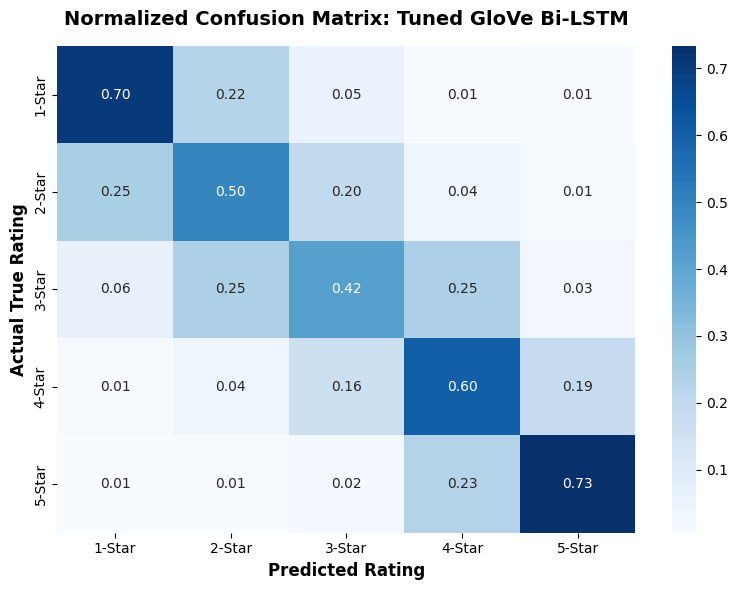

In [ ]:
# ======================
# PREDICTION ON TEST SET
# ======================
print("--- Loading Best Models ---")
baseline_model = load_model('best_lstm_baseline_model.keras')
advanced_model = load_model('best_glove_bilstm_model.keras')
tuned_model = load_model('best_tuned_glove_bilstm_model.keras')

print("\n--- Generating Predictions on Test Set ---")
print("Evaluating Baseline LSTM...")
y_test_probs_base = baseline_model.predict(X_test_pad, verbose=0)
y_test_preds_base = np.argmax(y_test_probs_base, axis=1)

print("Evaluating Advanced GloVe Bi-LSTM...")
y_test_probs_adv = advanced_model.predict(X_test_pad, verbose=0)
y_test_preds_adv = np.argmax(y_test_probs_adv, axis=1)

print("Evaluating Tuned GloVe Bi-LSTM...")
y_test_probs_tuned = tuned_model.predict(X_test_pad, verbose=0)
y_test_preds_tuned = np.argmax(y_test_probs_tuned, axis=1)

# Binarize labels for PR-AUC calculation
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

# --- Calculate Metrics: Baseline ---
f1_base = f1_score(y_test, y_test_preds_base, average='weighted')
pr_auc_base = average_precision_score(y_test_bin, y_test_probs_base, average='weighted')
bal_acc_base = balanced_accuracy_score(y_test, y_test_preds_base)

# --- Calculate Metrics: Advanced ---
f1_adv = f1_score(y_test, y_test_preds_adv, average='weighted')
pr_auc_adv = average_precision_score(y_test_bin, y_test_probs_adv, average='weighted')
bal_acc_adv = balanced_accuracy_score(y_test, y_test_preds_adv)

# --- Calculate Metrics: Tuned ---
f1_tuned = f1_score(y_test, y_test_preds_tuned, average='weighted')
pr_auc_tuned = average_precision_score(y_test_bin, y_test_probs_tuned, average='weighted')
bal_acc_tuned = balanced_accuracy_score(y_test, y_test_preds_tuned)

# --- Determine the Best Model ---
model_performances = {
    "Baseline LSTM": (f1_base, y_test_preds_base),
    "Advanced GloVe Bi-LSTM": (f1_adv, y_test_preds_adv),
    "Tuned GloVe Bi-LSTM": (f1_tuned, y_test_preds_tuned)
}

best_model_name = max(model_performances, key=lambda k: model_performances[k][0])
best_preds = model_performances[best_model_name][1]

# --- Print Side-by-Side Comparison ---
print("\n======================================================================")
print("                    FINAL TEST SET PERFORMANCE                        ")
print("======================================================================")
print(f"Metric                 | Baseline | GloVe Bi-LSTM | Tuned Bi-LSTM")
print("----------------------------------------------------------------------")
print(f"Weighted F1-Score      | {f1_base:.4f}   | {f1_adv:.4f}        | {f1_tuned:.4f}")
print(f"Weighted PR-AUC        | {pr_auc_base:.4f}   | {pr_auc_adv:.4f}        | {pr_auc_tuned:.4f}")
print(f"Balanced Accuracy      | {bal_acc_base:.4f}   | {bal_acc_adv:.4f}        | {bal_acc_tuned:.4f}")
print("======================================================================\n")

print(f"Best Performing Model: {best_model_name}\n")

# --- Detailed Classification Report for the Best Model ---
print(f"--- Detailed Classification Report: {best_model_name} ---")
print(classification_report(y_test, best_preds))

# ==============================
# CONFUSION MATRIX VISUALIZATION
# ==============================
print(f"--- Plotting Normalized Confusion Matrix for {best_model_name} ---")

# Generate Normalized Confusion Matrix
cm = confusion_matrix(y_test, best_preds, normalize='true')

# Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['1-Star', '2-Star', '3-Star', '4-Star', '5-Star'],
            yticklabels=['1-Star', '2-Star', '3-Star', '4-Star', '5-Star'])

# Add academic styling for the report
plt.title(f'Normalized Confusion Matrix: {best_model_name}', pad=15, fontsize=14, fontweight='bold')
plt.ylabel('Actual True Rating', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Rating', fontsize=12, fontweight='bold')
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
# Navigate back to main directory
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/F20AA - Coursework datasets/Coursework 2/

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1UDxVJBab-IBfTtVmoZr15F0yrlRH7iiY/F20AA - Coursework datasets/Coursework 2


## State-of-the-Art Transformer

In this section, we transition to state-of-the-art sequence modelling by implementing, training, and testing two highly robust, heavily pre-trained Transformer architectures: RoBERTa-Large and ELECTRA-Large.

To rigorously evaluate how these massive models adapt to our specific review dataset, we conduct two distinct experimental studies before evaluating the two resulting best performing transformer models rerspectively on our unseen test set:

1. **RoBERTa-Large:** We implement a progressive layer unfreezing strategy to test the model's adaptability. We sequentially evaluate a completely frozen network (Experiment A), a partially unfrozen network targeting the top 2 layers (Experiment B), and finally, a fully unfrozen network (Experiment C).

2. **ELECTRA-Large:** Operating under the established finding (from RoBERTa-Large experimentations above) that full fine-tuning (full layer unfreezing) yields superior results, our ELECTRA experiments maintain a completely unfrozen backbone. Instead, we conduct a rigorous hyperparameter sweep to identify the optimal learning rate ($3 \times 10^{-5}$, $8 \times 10^{-5}$, and $1 \times 10^{-4}$) for maximum stability and metric performance.

**Hardware Acceleration (Leveraging Google Colab's v5e-1 TPU):** Due to the immense computational overhead of fine-tuning the 355 million parameters of the RoBERTa-Large architecture, standard Colab GPU (T4 GPU) environments are highly susceptible to immediate memory exhaustion (OOM) and extremely slow iteration speeds. To mathematically facilitate this massive progressive fine-tuning pipeline, we leverage Google Colab's v5e-1 TPU (Tensor Processing Unit) and initialize the PyTorch XLA compiler for high-throughput, `bf16` precision training.

###TPU Environment Mapping
To execute the hardware acceleration strategy, we first install the PyTorch XLA library and explicitly instruct the Colab runtime environment to map all subsequent tensor operations to the connected TPU (v5e-1 TPU).

Crucially, to accommodate the immense memory requirements of both the RoBERTa-Large and ELECTRA-Large architectures (each exceeding 330 million parameters), we configure the environment variables to force the XLA compiler into 16-bit Brain Floating-Point (bf16) precision prior to initialization. This mathematical downcasting strictly halves the memory footprint of the model weights and gradients compared to standard 32-bit floats. This optimization exponentially increases computational throughput and prevents Out-Of-Memory (OOM) failures, all while maintaining the neural networks' predictive stability.

In [ ]:
# Install the PyTorch XLA library specifically for Colab TPUs
!pip install torch_xla[tpu] -f https://storage.googleapis.com/libtpu-releases/index.html

import os
# Instruct system to use TPU
os.environ['PJRT_DEVICE'] = 'TPU'

# Force 16-bit brain floating-point precision before importing XLA
os.environ['XLA_USE_BF16'] = '1'

import torch_xla
import torch_xla.core.xla_model as xm

device = torch_xla.device()
print(f"TPU Successfully Connected! Device: {device}")

Looking in links: https://storage.googleapis.com/libtpu-releases/index.html
TPU Successfully Connected! Device: xla:0


###Optimizing Sequence Length for Computational Efficiency

Transformer models scale quadratically in memory usage based on their input sequence length. Because we are leveraging massive architectures like roberta-large (355 million parameters) and electra-large (335 million parameters), utilizing the maximum 512-token window would immediately exhaust the v5e-1 TPU's memory and trigger system failures.

To find the optimal balance between preserving the semantic context of the reviews and satisfying the strict hardware constraints of using these model architectures, we profile the token length distribution of our training dataset. By identifying a strategic percentile cutoff, we can establish a `max_length` that safely truncates long outliers while preserving the complete textual context for the overwhelming majority of the data.

In [ ]:
import pandas as pd
import numpy as np
from transformers import RobertaTokenizer


# Load data for inspection
df = pd.read_csv("Transformers_preprocessed/transformer_train_clean.csv")

# Initialize the Roberta tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-large')

train_texts = df['transformer_text'].astype(str).tolist()
token_lengths = [len(tokenizer.encode(text, add_special_tokens=True)) for text in train_texts]

# Find the 84th percentile
optimal_length_84 = int(np.percentile(token_lengths, 84))

# Find the 85th percentile
optimal_length_85 = int(np.percentile(token_lengths, 85))

print(f"Average token length: {np.mean(token_lengths):.0f}")
print(f"Maximum token length: {np.max(token_lengths)}")
print(f"84% of the training texts are {optimal_length_84} tokens or less.")
print(f"85% of the training texts are {optimal_length_85} tokens or less.")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (593 > 512). Running this sequence through the model will result in indexing errors


Average token length: 73
Maximum token length: 2897
84% of the training texts are 124 tokens or less.
85% of the training texts are 130 tokens or less.


**Observation and Hyperparameter Selection:**

The token length distribution analysis reveals that the average review length is only 73 tokens, with 84% of the training dataset consisting of 124 tokens or less, and 85% of the training datatset consisting of 130 tokens or less. Based on this evidence, we establish the tokenizer's `max_length` hyperparameter at 128.

By dynamically optimizing the sequence length to 128, we ensure that more than 84% of our training dataset retains its complete semantic context without any truncation. While only the remaining less than 16% of the training dataset (the longer outliers) undergoes truncation, the core sentiment of a review is typically established within the first few sentences. This strategic 128-token boundary allows us to successfully train both the massive `roberta-large` and `electra_large` architectures on predominantly untruncated data while avoiding catastrophic memory exhaustion.

### RoBERTa-Large

####Defining the Experiment Architecture
The following block establishes the core infrastructure for the experiments. It initializes the `roberta-large` tokenizer (enforcing our data-driven `max_length` of 128), constructs the PyTorch `Dataset` objects, and defines the metric calculation (including a specific truncation step to handle static TPU matrix padding).

Crucially, it defines the master `run_roberta_large_experiment` function which dynamically controls layer unfreezing, optimal learning rates, and early stopping criteria.

In [ ]:
import pandas as pd
import numpy as np
import torch
import os
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from transformers import EarlyStoppingCallback
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Load data, transformer model, and tokenizer
df = pd.read_csv("Transformers_preprocessed/transformer_train_clean.csv")
X_train, X_val, y_train, y_val = train_test_split(df['transformer_text'].astype(str), df['rating'] - 1, test_size=0.2, random_state=17)

model_name = 'roberta-large'
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenize the data using the data-driven max_length, static tokenization to be TPU compliant
print("Tokenizing datasets with static padding...")
train_encodings = tokenizer(X_train.tolist(), truncation=True, padding='max_length', max_length=128, return_tensors='pt')
val_encodings = tokenizer(X_val.tolist(), truncation=True, padding='max_length', max_length=128, return_tensors='pt')

# Create a custom PyTorch Dataset
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels.values)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, y_train)
val_dataset = ReviewDataset(val_encodings, y_val)

# Define the metric (Weighted F1)
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    # The TPU pads predictions to keep matrix shapes perfectly static. This chops off the dummy padding so sklearn doesn't crash.
    min_len = min(len(labels), len(preds))
    labels = labels[:min_len]
    preds = preds[:min_len]

    f1 = f1_score(labels, preds, average='weighted')
    return {'eval_weighted_f1': f1}

# The experiment runner function
def run_roberta_large_experiment(experiment_name, freeze_layers=True, num_unfrozen_top_layers=0):
    print(f"\n" + "="*50)
    print(f"--- Running {model_name.upper()}: {experiment_name} ---")
    print("="*50)

    # Local paths (For fast checkpointing during training)
    local_model_path = f'/content/results_roberta_large_{experiment_name}'
    local_log_path = f'/content/logs_roberta_large_{experiment_name}'

    # Final path (For saving the final winner model properly)
    drive_final_path = f'./roberta_large/models/results_{experiment_name}_final_best'
    os.makedirs(drive_final_path, exist_ok=True)

    # Load the fresh new RoBERTa-Large model for each experiment
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=5)

    if freeze_layers:
        # Freeze all layers first (Experiment A)
        for param in model.roberta.parameters():
            param.requires_grad = False

        # Unfreeze specific top layers if requested (Experiment B)
        if num_unfrozen_top_layers > 0:
            for layer in model.roberta.encoder.layer[-num_unfrozen_top_layers:]:
                for param in layer.parameters():
                    param.requires_grad = True

    # Define the learning rate based on the specific experiment
    if experiment_name == "Frozen Base":
        # Most aggresive training for the classification head
        optimal_lr = 3e-4
    elif experiment_name == "Top 2 Unfrozen":
        # Moderately aggressive training for the classification head and 2 pre-trained transformer layers
        optimal_lr = 1e-4
    else: # "Fully Unfrozen"
        # Slightly aggresive but still safely updating all 355 million parameters in roberta-large
        optimal_lr = 7e-5

    # Setup training arguments (TPU optimized)
    training_args = TrainingArguments(
        output_dir=local_model_path,
        num_train_epochs=4,               # Standard number of epochs (3-10 epochs)
        # Settings optimized for Google Colab's v5e-1 TPU's RAM (47.05 GB RAM), any number higher than this have resulted in Out-Of-Memory crashes
        per_device_train_batch_size=64,   # Good training batch size that allows TPU to be able to run sufficiently fast without OOM issues and allows a good number of weight updates per epoch
        per_device_eval_batch_size=128,
        warmup_ratio=0.1,                 # 10% of the total scheduled weight update steps for warmup
        weight_decay=0.01,                # L2 Regularization
        logging_dir=local_log_path,
        logging_strategy="epoch",
        eval_strategy="epoch",
        learning_rate=optimal_lr,
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_weighted_f1",
        dataloader_pin_memory=False,
        bf16=True,                        # BF16 precision format for using TPU efficiently
        optim="adamw_torch_xla",          # Utilize the TPU efficiently
        dataloader_drop_last=True         # Prevents shape shifting crashes
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]  #Early stopping (2 epochs)
    )

    trainer.train()

    # Plot the learning curve for each experiment
    history = trainer.state.log_history
    epochs = [x['epoch'] for x in history if 'eval_weighted_f1' in x]
    f1_scores = [x['eval_weighted_f1'] for x in history if 'eval_weighted_f1' in x]

    if epochs and f1_scores:
        plt.figure(figsize=(8, 4))
        sns.lineplot(x=epochs, y=f1_scores, marker='o', linewidth=2, color='crimson')
        plt.title(f"RoBERTa-Large {experiment_name}: Validation F1 Score Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Weighted F1 Score")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

    eval_results = trainer.evaluate()

    # Saves the absolute best trained model to the designated folder
    trainer.save_model(f"{drive_final_path}")
    tokenizer.save_pretrained(f"{drive_final_path}")

    return eval_results['eval_weighted_f1']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing datasets with static padding...


####Executing the Experiments A, B, and C

With the experiment architecture defined (and the v5e-1 TPU already initialized), we now execute the three experiments on the `roberta-large` model. The following cells train the completely frozen network (Experiment A: Frozen Base), a partially unfrozen network (Experiment B: Top 2 Unfrozen), and finally a fully unfrozen network (Experiment C: Fully Unfrozen).


--- Running ROBERTA-LARGE: Frozen Base ---


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated

Epoch,Training Loss,Validation Loss,Weighted F1
1,0.142222,0.962552,0.556119
2,0.142222,0.939939,0.560809
3,0.142222,0.931493,0.564773
4,0.142222,0.931727,0.564695


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

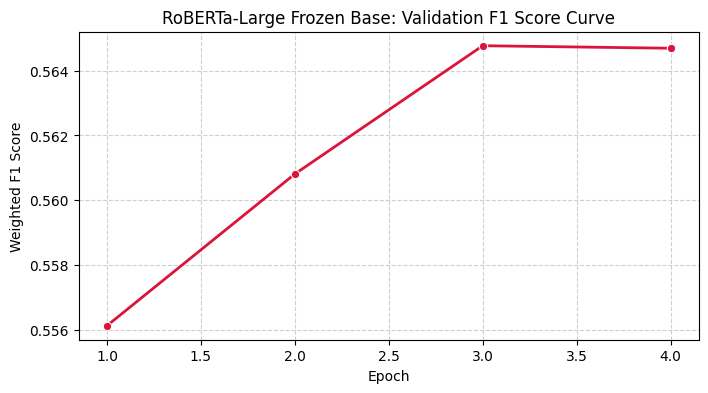

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


FINAL WEIGHTED F1 SCORE FOR ROBERTA-LARGE FROZEN BASE: 0.5648


In [ ]:
# Experiment A: Frozen Base (Completely frozen network, only train the classification head)
frozen_base_results = run_roberta_large_experiment("Frozen Base", freeze_layers=True, num_unfrozen_top_layers=0)

print(f"\nFINAL WEIGHTED F1 SCORE FOR ROBERTA-LARGE FROZEN BASE: {frozen_base_results:.4f}")


--- Running ROBERTA-LARGE: Top 2 Unfrozen ---


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated

Epoch,Training Loss,Validation Loss,Weighted F1
1,0.142222,0.733885,0.680578
2,0.093889,0.717296,0.690336


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Weighted F1
1,0.142222,0.733885,0.680578
2,0.093889,0.717296,0.690336
3,0.086667,0.715378,0.691431
4,0.085556,0.716519,0.691877


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

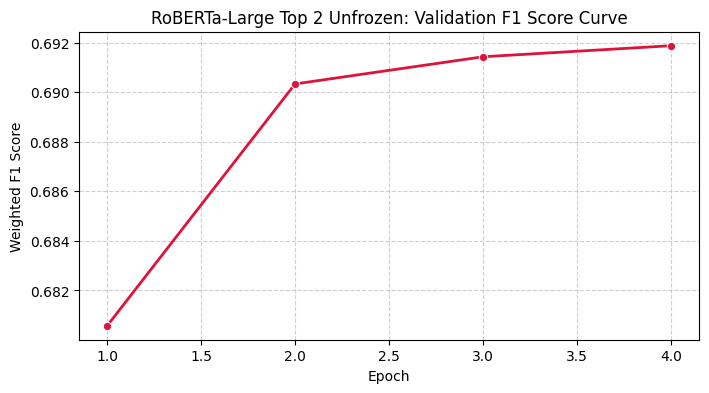

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

WEIGHTED F1 SCORE FOR Top 2 UNFROZEN: 0.6919


In [ ]:
# Experiment B: Top 2 Unfrozen (Unfreeze the top 2 layers of RoBERTa)
top2_unfrozen_results = run_roberta_large_experiment("Top 2 Unfrozen", freeze_layers=True, num_unfrozen_top_layers=2)

print(f"WEIGHTED F1 SCORE FOR Top 2 UNFROZEN: {top2_unfrozen_results:.4f}")


--- Running ROBERTA-LARGE: Fully Unfrozen ---


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated

Epoch,Training Loss,Validation Loss,Weighted F1
1,0.142222,0.720634,0.692553
2,0.077222,0.692691,0.711927
3,0.072778,0.698446,0.710932
4,0.073333,0.701194,0.711085


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

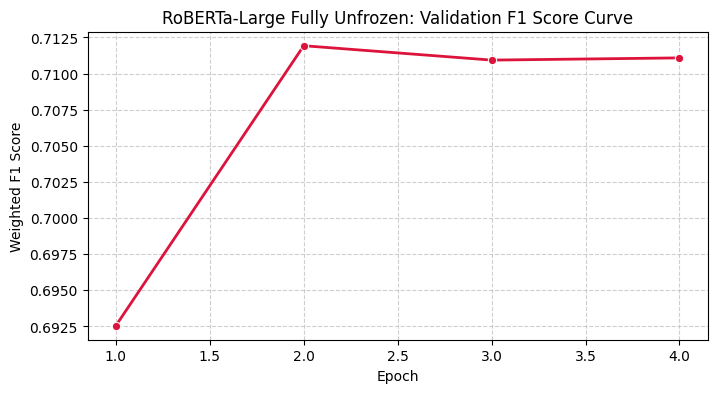

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


FINAL WEIGHTED F1 SCORE FOR ROBERTA-LARGE FULLY UNFROZEN: 0.7120


In [ ]:
# Experiment C: Fully Unfrozen (Full fine-tuning)
full_fine_tuning_results = run_roberta_large_experiment("Fully Unfrozen", freeze_layers=False)

print(f"\nFINAL WEIGHTED F1 SCORE FOR ROBERTA-LARGE FULLY UNFROZEN: {full_fine_tuning_results:.4f}")

#### Weighted F1-Score Performance Analysis Across the Progressive Unfreezing Experiments

With all three experiments complete, we now aggregate the highest Weighted F1-scores achieved on the validation set from each experiment training run. Visualizing this progression allows us to quantify the impact of deep architectural fine-tuning on the roberta-large model's predictive performance.

/tmp/ipykernel_470/3033306623.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(roberta_results.keys()), y=list(roberta_results.values()), palette='crest')


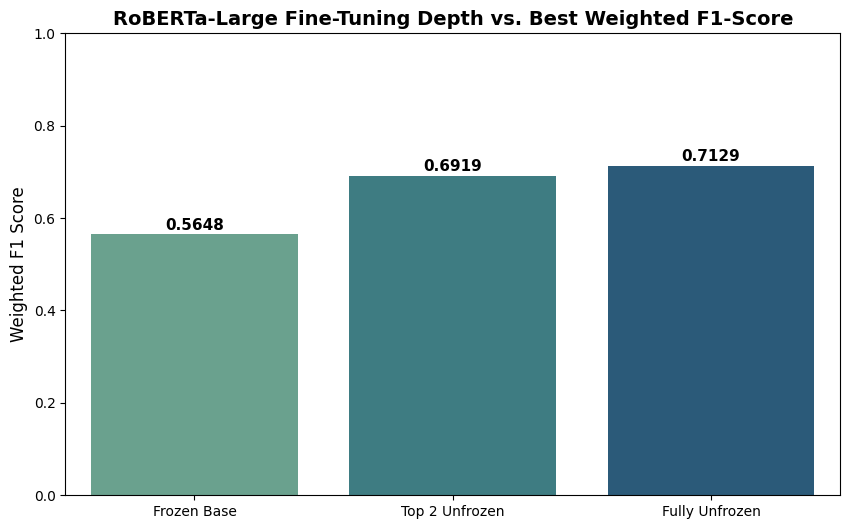

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Experiment results (Weighted F1-score of the best model on the validation dataset from each experiment)
roberta_results = {
    'Frozen Base': 0.5648,
    'Top 2 Unfrozen': 0.6919,
    'Fully Unfrozen': 0.7129
}

# Plot the experiment results
plt.figure(figsize=(10, 6))
# Create the bar plot
sns.barplot(x=list(roberta_results.keys()), y=list(roberta_results.values()), palette='crest')

# Formatting
plt.title('RoBERTa-Large Fine-Tuning Depth vs. Best Weighted F1-Score', fontsize=14, fontweight='bold')
plt.ylabel('Weighted F1 Score', fontsize=12)
plt.ylim(0, 1.0)

# Add the exact weighted F1-score numbers on top of each bar
for i, v in enumerate(roberta_results.values()):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)

plt.show()

**Architectural Insights and Weighted F1-Score Performance Analysis:**

The visualization of the results demonstrates a clear, direct correlation between the depth of architectural fine-tuning and the roberta-large model's predictive accuracy. The variance in the Weighted F1-scores can be attributed to how deeply the pre-trained weights were allowed to adapt to the specific linguistic nuances of the target dataset:

**Experiment A (Frozen Base - 0.5648):** Restricting weight updates purely to the classification head yielded the lowest Weighted F1-score performance. In this state, the 355-million parameter RoBERTa architecture acts merely as a static feature extractor. While the model possesses excellent general English comprehension (having been pre-trained on massive corpora), those locked semantic representations were unable to shift and adapt to the highly specific vocabulary, sarcasm, or context relevant to these specific reviews.

**Experiment B (Top 2 Unfrozen - 0.6919):** Unlocking the top two Transformer layers resulted in a massive performance surge. In deep neural networks, lower layers typically capture fundamental linguistic syntax, while the highest layers capture abstract, task-specific semantics. By unfreezing these 2 top layers, we allowed the model's highest level attention mechanisms to dynamically rewire themselves, successfully learning to prioritize sentiment-critical context before passing the data to the classification head.

**Experiment C (Fully Unfrozen - 0.7129):** Completely unfreezing the architecture yielded the peak predictive performance for the roberta-large model. This confirms that for maximum classification accuracy, the network requires end-to-end gradient flow. Every parameter, from the earliest embedding layers to the final attention heads, underwent deep contextual realignment to more accurately map the specific linguistic patterns of the dataset.

**Conclusion and Final Selection:** Ultimately, the above data shows that the Fully Unfrozen configuration / experiment yielded the RoBERTa-Large model with the highest predictive performance (the highest weighted F1-score). Therefore, we select this fully fine-tuned roberta-large checkpoint as the final best model for our RoBERTa classification pipeline.

#### Final Evaluation on Unseen Test Dataset
Following the conclusion of our progressive unfreezing experiments, we establish that our Fully Unfrozen experiment yielded the RoBERTa-Large model with the highest (best) weighted F1-score. We now load this best performing model (on weighted F1-score within this pipeline) to evaluate its predictive performance on the unseen test dataset

Because our initial dataset analysis revealed a severe class imbalance (heavily skewed towards 1-star and 4-star reviews), we evaluate the best model using three robust metrics which were decided during the initial analysis phase, designed for imbalanced distributions: Weighted F1 Score, Balanced Accuracy, and PR-AUC.

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Running inferences on the unseen test dataset...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


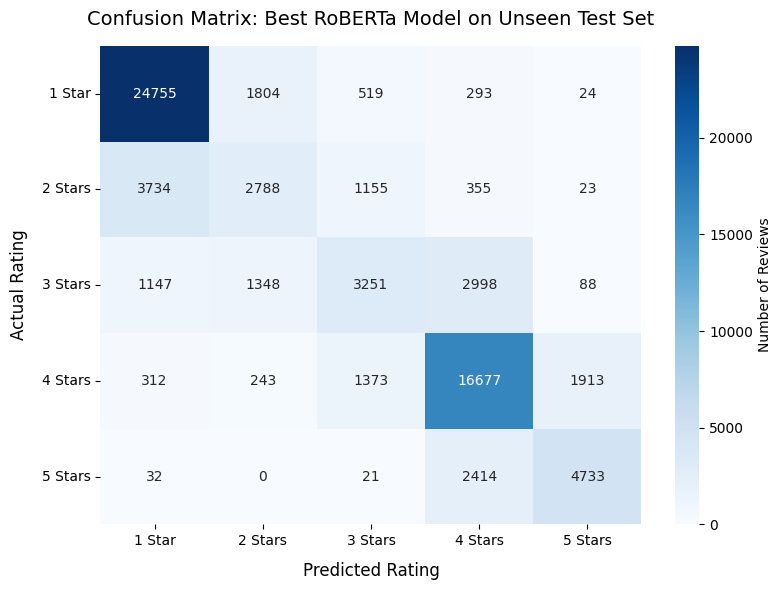


FINAL TEST SET PERFORMANCE (Best RoBERTa Model)
Weighted F1-Score:  0.7122
Balanced Accuracy:  0.6176
Weighted PR-AUC:    0.7633


In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer
from sklearn.metrics import f1_score, balanced_accuracy_score, average_precision_score, confusion_matrix
from sklearn.preprocessing import label_binarize

# Load the best RoBERTa model and tokenizer
best_model_path = './roberta_large/models/results_Fully Unfrozen_final_best'
tokenizer = RobertaTokenizer.from_pretrained(best_model_path)
model = RobertaForSequenceClassification.from_pretrained(best_model_path)

# Load the unseen, cleaned test dataset
df_test = pd.read_csv("Transformers_preprocessed/transformer_test_clean.csv")

# Aligning ratings to 0-4 classes (same as training)
X_test = df_test['transformer_text'].astype(str)
y_test = df_test['rating'] - 1

# Tokenize the data using the data-driven max_length
test_encodings = tokenizer(X_test.tolist(), truncation=True, padding='max_length', max_length=128)

# Initialize the custom PyTorch Dataset defined earlier
test_dataset = ReviewDataset(test_encodings, y_test)

# Initialize trainer
trainer = Trainer(model=model)

# Generate predictions
print("Running inferences on the unseen test dataset...")
raw_predictions = trainer.predict(test_dataset)

# Process the outputs
logits = raw_predictions.predictions
labels = raw_predictions.label_ids

# TPU padding fix
min_len = min(len(labels), len(logits))
labels_clean = labels[:min_len]
logits_clean = logits[:min_len]

# Convert logits to probabilities (Needed for PR-AUC)
probs = torch.nn.functional.softmax(torch.tensor(logits_clean), dim=-1).numpy()

# Get hard class predictions (Needed for F1-score and Accuracy)
preds = np.argmax(probs, axis=1)

# Calculate the final metrics
# Weighted F1-Score
test_f1 = f1_score(labels_clean, preds, average='weighted')

# Balanced Accuracy
test_bal_acc = balanced_accuracy_score(labels_clean, preds)

# PR-AUC (Weighted)
labels_binarized = label_binarize(labels_clean, classes=[0, 1, 2, 3, 4])
test_pr_auc = average_precision_score(labels_binarized, probs, average='weighted')

# Plot the Confusion Matrix
cm = confusion_matrix(labels_clean, preds)
class_names = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Number of Reviews'})
plt.title('Confusion Matrix: Best RoBERTa Model on Unseen Test Set', fontsize=14, pad=15)
plt.xlabel('Predicted Rating', fontsize=12, labelpad=10)
plt.ylabel('Actual Rating', fontsize=12, labelpad=10)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print the final report
print("\n" + "="*50)
print("FINAL TEST SET PERFORMANCE (Best RoBERTa Model)")
print("="*50)
print(f"Weighted F1-Score:  {test_f1:.4f}")
print(f"Balanced Accuracy:  {test_bal_acc:.4f}")
print(f"Weighted PR-AUC:    {test_pr_auc:.4f}")
print("="*50)

### ELECTRA-Large

#### Defining Electra Experimentation

The following block establishes the core infrastructure for the experiments. It initialises the `electra-large` tokenizer (enforcing our data-driven max_length of 128), constructs the PyTorch Dataset objects, and defines the metric calculation (including a specific truncation step to handle static TPU matrix padding).

Crucially, it defines the master `run_electra_lr_experiment` function. With all transformer layers intentionally left fully unfrozen for complete fine-tuning, this function dynamically tests different learning rate values to sweep for the optimal hyperparameter configuration, alongside early stopping criteria to prevent overtraining.

In [ ]:
import pandas as pd
import numpy as np
import torch
import os
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from transformers import EarlyStoppingCallback
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Load data and tokenizer
df = pd.read_csv("Transformers_preprocessed/transformer_train_clean.csv")
X_train, X_val, y_train, y_val = train_test_split(df['transformer_text'].astype(str), df['rating'] - 1, test_size=0.2, random_state=17)

# Load ELECTRA
model_name = 'google/electra-large-discriminator'
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Static Tokenization, data-driven max sequence length 'max_length' of 128
print("Tokenizing datasets with static padding...")
train_encodings = tokenizer(X_train.tolist(), truncation=True, padding='max_length', max_length=128, return_tensors='pt')
val_encodings = tokenizer(X_val.tolist(), truncation=True, padding='max_length', max_length=128, return_tensors='pt')

# Create a custom PyTorch Dataset
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels.values)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, y_train)
val_dataset = ReviewDataset(val_encodings, y_val)

# Define the metric (Weighted F1)
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    # Chop off the dummy padding so sklearn doesn't crash
    min_len = min(len(labels), len(preds))
    labels = labels[:min_len]
    preds = preds[:min_len]

    f1 = f1_score(labels, preds, average='weighted')
    return {'eval_weighted_f1': f1}

# The experiment runner Function
def run_electra_lr_experiment(experiment_name, learning_rate_val):
    print(f"\n" + "="*50)
    print(f"--- Running ELECTRA-Large LR Tuning: {experiment_name} ---")
    print(f"--- Learning Rate: {learning_rate_val} ---")
    print("="*50)

    local_model_path = f'/content/results_electra_{experiment_name}'
    local_log_path = f'/content/logs_electra_{experiment_name}'
    drive_final_path = f'./electra_large/models/results_{experiment_name}_final_best'
    os.makedirs(drive_final_path, exist_ok=True)

    # Load a fresh ELECTRA model for each run
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=5)

    # Setup training arguments (TPU Optimized, using the dynamic learning rate)
    training_args = TrainingArguments(
        output_dir=local_model_path,
        num_train_epochs=4,               # Standard number of epochs (3-10 epochs)
        # Settings optimized for Google Colab's v5e-1 TPU's RAM (47.05 GB RAM), any number higher than this have resulted in Out-Of-Memory crashes
        per_device_train_batch_size=64,   # Good training batch size that allows TPU to be able to run sufficiently fast without OOM issues and allows a good number of weight updates per epoch
        per_device_eval_batch_size=128,
        warmup_ratio=0.1,                 # 10% of the total scheduled weight update steps for warmup
        weight_decay=0.01,                # L2 Regularization
        logging_dir=local_log_path,
        logging_strategy="epoch",
        eval_strategy="epoch",
        learning_rate=learning_rate_val,  # Learning rate passed dynamically here
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_weighted_f1",
        dataloader_pin_memory=False,
        bf16=True,                        # BF16 precision format for using TPU efficiently
        optim="adamw_torch_xla",          # Utilize the TPU efficiently
        dataloader_drop_last=True         # Prevents shape shifting crashes
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]  #Early stopping (2 epochs)
    )

    trainer.train()

    # Plot the learning curve for this specific LR
    history = trainer.state.log_history
    epochs = [x['epoch'] for x in history if 'eval_weighted_f1' in x]
    f1_scores = [x['eval_weighted_f1'] for x in history if 'eval_weighted_f1' in x]

    if epochs and f1_scores:
        plt.figure(figsize=(8, 4))
        sns.lineplot(x=epochs, y=f1_scores, marker='o', linewidth=2, color='darkorange')
        plt.title(f"ELECTRA-Large ({experiment_name}): Validation F1 Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Weighted F1 Score")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

    eval_results = trainer.evaluate()

    # Save the absolute best trained model from this LR run
    trainer.save_model(f"{drive_final_path}")
    tokenizer.save_pretrained(f"{drive_final_path}")

    return eval_results['eval_weighted_f1']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/668 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing datasets with static padding...


#### Executing Electra Experiments

With the experiment architecture defined (and the v5e-1 TPU already initialized), we now execute the three experiments on the `electra-large` model. The following cells train the completely unfrozen networks with learning rates of `3e-5`, `8e-5`, and finally `1e-4`.


--- Running ELECTRA-Large LR Tuning: LR_3e-5 ---
--- Learning Rate: 3e-05 ---


pytorch_model.bin:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: google/electra-large-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
-

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

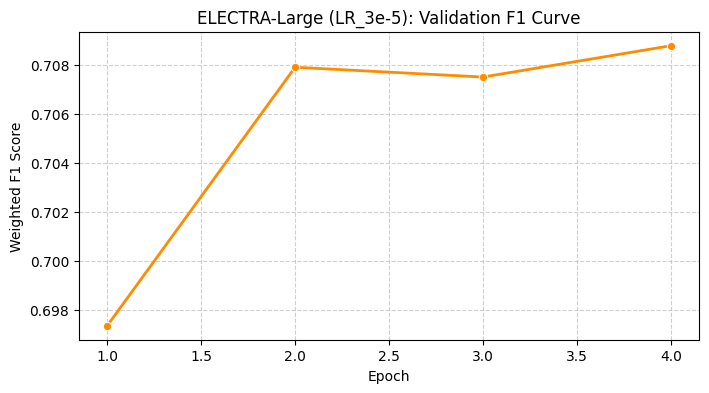

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

WEIGHTED F1 SCORE FOR LR 3e-5: 0.7088


In [ ]:
# Experiment 1: 3e-5 lr
lr_1_results = run_electra_lr_experiment("LR_3e-5", learning_rate_val=3e-5)
print(f"WEIGHTED F1 SCORE FOR LR 3e-5: {lr_1_results:.4f}")


--- Running ELECTRA-Large LR Tuning: LR_8e-5 ---
--- Learning Rate: 8e-05 ---


pytorch_model.bin:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: google/electra-large-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
-

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

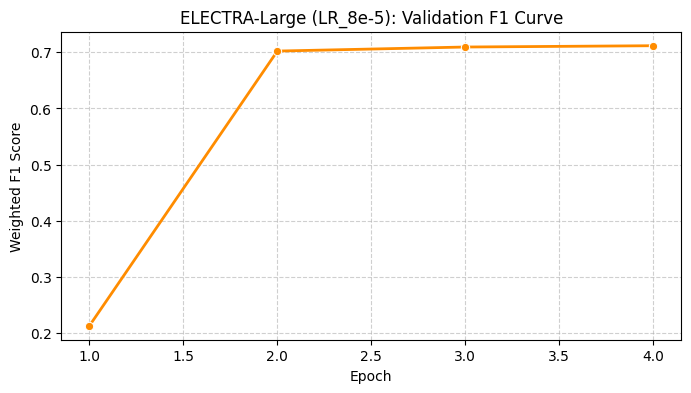

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

WEIGHTED F1 SCORE FOR LR 8e-5: 0.7117


In [ ]:
# Experiment 2: 8e-5 lr
lr_2_results = run_electra_lr_experiment("LR_8e-5", learning_rate_val=8e-5)
print(f"WEIGHTED F1 SCORE FOR LR 8e-5: {lr_2_results:.4f}")


--- Running ELECTRA-Large LR Tuning: LR_1e-4 ---
--- Learning Rate: 0.0001 ---


pytorch_model.bin:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: google/electra-large-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings_project.bias                   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
-

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

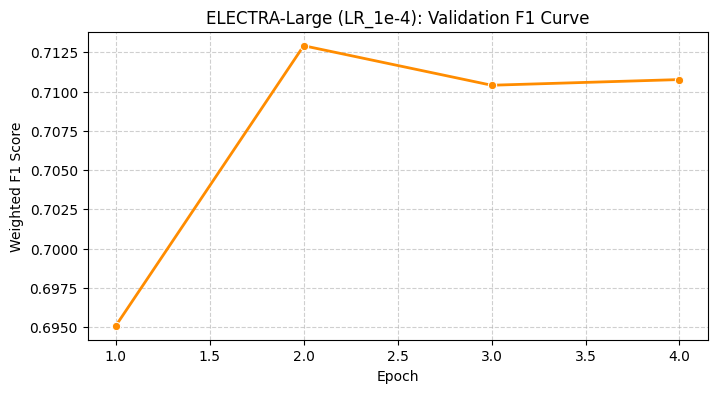

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

WEIGHTED F1 SCORE FOR LR 1e-4: 0.7132


In [ ]:
# Experiment 3: 1e-4 lr
lr_3_results = run_electra_lr_experiment("LR_1e-4", learning_rate_val=1e-4)
print(f"WEIGHTED F1 SCORE FOR LR 1e-4: {lr_3_results:.4f}")

#### Weighted F1-Score Performance Analysis Across the Different Learning Rate Values

With all three experiments complete, we now aggregate the highest weighted F1-scores achieved on the validation set from each experiment training run. Visualizing this progression allows us to quantify the impact of hyperparameter fine-tuning on the `electra-large` model's predictive performance.

/tmp/ipykernel_1442/731627831.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(roberta_results.keys()), y=list(roberta_results.values()), palette='crest')


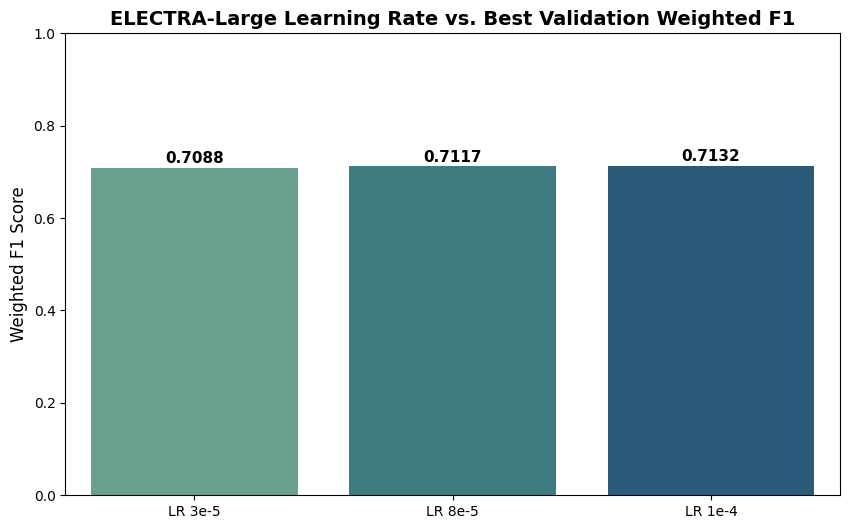

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Experiment results
roberta_results = {
    'LR 3e-5': 0.7088,
    'LR 8e-5': 0.7117,
    'LR 1e-4': 0.7132
}

# Plot the experiment results
plt.figure(figsize=(10, 6))
# Create the bar plot
sns.barplot(x=list(roberta_results.keys()), y=list(roberta_results.values()), palette='crest')

# Formatting
plt.title('ELECTRA-Large Learning Rate vs. Best Validation Weighted F1', fontsize=14, fontweight='bold')
plt.ylabel('Weighted F1 Score', fontsize=12)
plt.ylim(0, 1.0)

# Add the exact weighted F1-score numbers on top of each bar
for i, v in enumerate(roberta_results.values()):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)

plt.show()

#### Final Evaluation on Unseen Test Dataset

Following the conclusion of our learning rate value experiments, we establish that the experiment with a learning rate value of `1e-4` yielded the `electra-large` model with the highest (best) weighted F1-score. We now load this best performing model (on weighted F1-score within this pipeline) to evaluate its predictive performance on the unseen test dataset


The testing conducted shall follow the same structure and use the same metrics (Weighted F1 Score, Balanced Accuracy, and PR-AUC) as the previous transformer model. This ensures dataset imbalance is taken into account, and a fair comparison can be made between the different classification models.

Loading champion model from: ./electra_large/models/results_LR_1e-4_final_best


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Running inferences on the unseen test dataset...


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


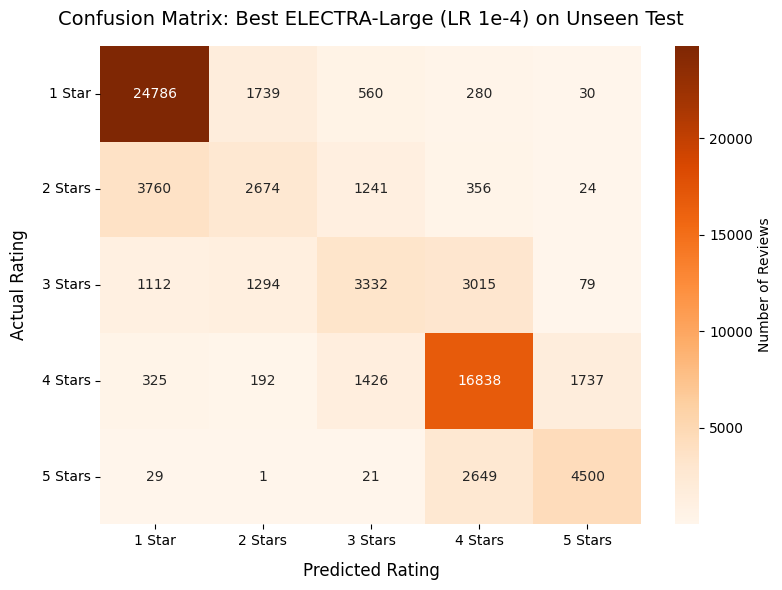


FINAL TEST SET PERFORMANCE (Best ELECTRA-Large - LR 1e-4)
Weighted F1-Score:  0.7106
Balanced Accuracy:  0.6119
Weighted PR-AUC:    0.7625


In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from sklearn.metrics import f1_score, balanced_accuracy_score, average_precision_score, confusion_matrix
from sklearn.preprocessing import label_binarize

# Load the champion ELECTRA model
champion_model_path = f'./electra_large/models/results_LR_1e-4_final_best'

print(f"Loading champion model from: {champion_model_path}")
tokenizer = AutoTokenizer.from_pretrained(champion_model_path)
model = AutoModelForSequenceClassification.from_pretrained(champion_model_path)

# Load the unseen, cleaned test dataset
df_test = pd.read_csv("Transformers_preprocessed/transformer_test_clean.csv")

# Aligning ratings to 0-4 classes
X_test = df_test['transformer_text'].astype(str)
y_test = df_test['rating'] - 1

# Tokenize using the identical static parameters from training
test_encodings = tokenizer(X_test.tolist(), truncation=True, padding='max_length', max_length=128, return_tensors='pt')

# Initialize the custom PyTorch Dataset
test_dataset = ReviewDataset(test_encodings, y_test)

# Initialize trainer purely for prediction
trainer = Trainer(model=model)

# Generate predictions
print("Running inferences on the unseen test dataset...")
raw_predictions = trainer.predict(test_dataset)

logits = raw_predictions.predictions
labels = raw_predictions.label_ids

# TPU padding fix
min_len = min(len(labels), len(logits))
labels_clean = labels[:min_len]
logits_clean = logits[:min_len]

# Convert logits to probabilities
probs = torch.nn.functional.softmax(torch.tensor(logits_clean), dim=-1).numpy()

# Get hard class predictions
preds = np.argmax(probs, axis=1)

# Calculate the final metrics
test_f1 = f1_score(labels_clean, preds, average='weighted')
test_bal_acc = balanced_accuracy_score(labels_clean, preds)

labels_binarized = label_binarize(labels_clean, classes=[0, 1, 2, 3, 4])
test_pr_auc = average_precision_score(labels_binarized, probs, average='weighted')

# Plot the Confusion Matrix
cm = confusion_matrix(labels_clean, preds)
class_names = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Number of Reviews'})
plt.title(f'Confusion Matrix: Best ELECTRA-Large (LR 1e-4) on Unseen Test', fontsize=14, pad=15)
plt.xlabel('Predicted Rating', fontsize=12, labelpad=10)
plt.ylabel('Actual Rating', fontsize=12, labelpad=10)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print the final report
print("\n" + "="*50)
print(f"FINAL TEST SET PERFORMANCE (Best ELECTRA-Large - LR 1e-4)")
print("="*50)
print(f"Weighted F1-Score:  {test_f1:.4f}")
print(f"Balanced Accuracy:  {test_bal_acc:.4f}")
print(f"Weighted PR-AUC:    {test_pr_auc:.4f}")
print("="*50)

# Kaggle Submission  

## Single Model Kaggle Submission

The following section details the prediction pipeline for our Kaggle competition submission using our trained transformer model (one model). The process involves loading and preprocessing the unseen blind test set, tokenizing the text (based on the transformer model used), and running inference through the transformer model. Finally, the raw predictions are mapped back to the original 1-5 star rating scale and exported into a structured CSV file that strictly matches the specified Kaggle competition's submission format.

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer

# Load transformer model
best_model_path = './electra_large/models/results_LR_1e-4_final_best'
tokenizer = AutoTokenizer.from_pretrained(best_model_path)
model = AutoModelForSequenceClassification.from_pretrained(best_model_path)

# Load the official Kaggle blind test set
df_kaggle_test = pd.read_csv("test_kaggle.csv")

df_kaggle_test['clean_text'] = df_kaggle_test['text'].astype(str).apply(preprocess_for_transformers)

X_blind = df_kaggle_test['clean_text']

# Tokenize the blind data
blind_encodings = tokenizer(X_blind.tolist(), truncation=True, padding='max_length', max_length=512)

# Create a specialized Dataset class for unlabeled data
class UnlabeledReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

    def __len__(self):
        return len(self.encodings.input_ids)

blind_dataset = UnlabeledReviewDataset(blind_encodings)

# Initialize Trainer and predict
trainer = Trainer(model=model)
print("Running inferences on Kaggle's blind test set...")
raw_predictions = trainer.predict(blind_dataset)

# Process the outputs
logits = raw_predictions.predictions
preds_0_to_4 = np.argmax(logits, axis=1)

# Convert model outputs (0-4) back to the usual star ratings (1-5)
final_star_ratings = preds_0_to_4 + 1

# Create the exact submission format the Kaggle competition wants
submission_df = pd.DataFrame({
    'Id': df_kaggle_test['Id'],
    'Rating': final_star_ratings
})

# Export to CSV
submission_df.to_csv('submission6.csv', index=False)
print("submission6.csv successfully generated and ready for Kaggle upload")

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Running inferences on Kaggle's blind test set...


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


submission6.csv successfully generated and ready for Kaggle upload


## Ensemble Kaggle Submission

To maximize our predictive performance and robustness on the Kaggle test set, we implemented an ensemble strategy combining predictions from our two strongest models: RoBERTa-Large and ELECTRA-Large.

Rather than relying on simple hard-voting, we utilize a **Soft Voting** approach:
* We extract the raw logits from both models and convert them into probability distributions using a softmax function.
* We apply a weighted average to these probabilities: **45-50% RoBERTa-Large** and **50-55% ELECTRA-Large** (favoring ELECTRA based on its slightly better performance on the Kaggle test set as tested previously in the single model kaggle submission ).
* Memory management (`gc.collect()`) is enforced between the two inferences to prevent the TPU Out-Of-Memory (OOM) crashes.

By mathematically fusing these confidence scores, the ensemble leverages the strengths of both architectures. The final highest-probability classes are extracted, converted back to star ratings, and exported for the Kaggle competition submission.

In [ ]:
import pandas as pd
import numpy as np
import torch
import gc
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer

# Load and preprocess the Kaggle Test Set using the previously established text preprocessing pipeline for transformers
df_kaggle_test = pd.read_csv("test_kaggle.csv")
print("Preprocessing test data...")
df_kaggle_test['clean_text'] = df_kaggle_test['text'].astype(str).apply(preprocess_for_transformers)
X_blind = df_kaggle_test['clean_text'].tolist()

# Custom Dataset Class
class UnlabeledReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings
    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
    def __len__(self):
        return len(self.encodings.input_ids)

# MODEL 1: RoBERTa
print("\n--- Booting RoBERTa ---")
rob_path = './roberta_large/models/results_Fully Unfrozen_final_best'
rob_tokenizer = AutoTokenizer.from_pretrained(rob_path)
rob_model = AutoModelForSequenceClassification.from_pretrained(rob_path)

print("Tokenizing for RoBERTa...")
rob_encodings = rob_tokenizer(X_blind, truncation=True, padding='max_length', max_length=512)
rob_dataset = UnlabeledReviewDataset(rob_encodings)

print("Running RoBERTa Inference...")
rob_trainer = Trainer(model=rob_model)
rob_logits = rob_trainer.predict(rob_dataset).predictions

# Convert raw logits to probability percentages
rob_probs = F.softmax(torch.tensor(rob_logits), dim=-1).numpy()

# Clear memory so the TPU doesn't crash
del rob_model, rob_trainer, rob_dataset, rob_encodings
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

# MODEL 2: ELECTRA
print("\n--- Booting ELECTRA ---")
elec_path = './electra_large/models/results_LR_1e-4_final_best'
elec_tokenizer = AutoTokenizer.from_pretrained(elec_path)
elec_model = AutoModelForSequenceClassification.from_pretrained(elec_path)

print("Tokenizing for ELECTRA...")
elec_encodings = elec_tokenizer(X_blind, truncation=True, padding='max_length', max_length=512)
elec_dataset = UnlabeledReviewDataset(elec_encodings)

print("Running ELECTRA Inference...")
elec_trainer = Trainer(model=elec_model)
elec_logits = elec_trainer.predict(elec_dataset).predictions

# Convert raw logits to probability percentages
elec_probs = F.softmax(torch.tensor(elec_logits), dim=-1).numpy()

# CLEAR MEMORY
del elec_model, elec_trainer
gc.collect()

# The ensemble (Soft Voting)
roberta_weight = 0.45  # Slightly lower weightage for RoBERTa than ELECTRA since it scored slightly lower than ELECTRA in the single model Kaggle submission
electra_weight = 0.55  # Slightly higher weightage for ELECTRA than RoBERTa since it scored slightly higher than RoBERTa in the single model Kaggle submission

print("\n--- Fusing Model Probabilities ---")
# Mathematically apply the weights to the confidences
ensemble_probs = (rob_probs * roberta_weight) + (elec_probs * electra_weight)

# Extract the final class prediction from the fused probabilities
final_preds_0_to_4 = np.argmax(ensemble_probs, axis=1)

# Convert 0-4 back to the usual 1-5 star ratings
final_star_ratings = final_preds_0_to_4 + 1

# Export to CSV
submission_df = pd.DataFrame({
    'Id': df_kaggle_test['Id'],
    'Rating': final_star_ratings
})

submission_file = 'ensemble_roberta_electra_submission_7.csv'
submission_df.to_csv(submission_file, index=False)
print(f"\nSUCCESS! {submission_file} is ready for Kaggle upload.")

Preprocessing test data...

--- Booting RoBERTa ---


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Tokenizing for RoBERTa...
Running RoBERTa Inference...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



--- Booting ELECTRA ---


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Tokenizing for ELECTRA...
Running ELECTRA Inference...



--- Fusing Model Probabilities ---

SUCCESS! ensemble_roberta_electra_submission_7.csv is ready for Kaggle upload.


# Comparison and Deployment of Best-Peforming Model for Relabelling

This section evaluates the models trained in previous sessions to establish the optimal approach for dataset relabeling. Performance is compared across:

1. Naive Bayes
2. LSTM
3. RoBERTa-large
4. ELECTRA-large

**Weighted F1-Score**, **Weighted PR-AUC**, and **Balanced Accuracy** are utilized as the primary evaluation metrics to account for heavy class imbalance.

The newly relabeled dataset then serves as the foundation for downstream analysis, specifically topic modeling and word cloud generation, to extract distinct thematic insights from 1-star and 5-star reviews.



## Model Evaluation and Ensemble Relabeling Strategy

| Model Pipeline | Macro F1-Score | PR-AUC | Balanced Accuracy |
| :--- | :--- | :--- | :--- |
| Naive Bayes | 0.5934 | 0.6128 | 0.5022 |
| LSTM | 0.6370 | 0.6975 | 0.5907 |
| **RoBERTA-large** | **0.7122** | **0.6176** | **0.7633** |
| ELECTRA-large | 0.7106 | 0.6119 | 0.7625 |

An analysis of the performance metrics indicates that transformer-based architectures significantly outperform both Naive Bayes and LSTM baselines. RoBERTa-large emerged as the best-performing model, achieving the highest Macro F1-Score (0.7122) and Balanced Accuracy (0.7633). ELECTRA-large also demonstrated highly competitive results, closely tracking RoBERTa-large with a Macro F1-Score of 0.7106 and a Balanced Accuracy of 0.7625.

To maximize the reliability of the final predictions, a weighted ensemble strategy is adopted rather than relying on a single architecture. Mirroring successful methodologies established in robust predictive pipelines, a soft-voting ensemble combining both RoBERTa-large and ELECTRA-large is deployed. Because RoBERTa-large exhibited slightly superior overall performance, the soft-voting mechanism assigns a higher weight of **0.6** to its predictive probabilities, while ELECTRA-large receives a weight of **0.4**.

This weighted dual-transformer approach leverages the predictive strengths of both models to execute the final relabeling of the entire dataset. The newly relabeled dataset then serves as the foundation for downstream analysis, specifically topic modeling and word cloud generation, to extract distinct thematic insights from 1-star and 5-star reviews.


In [ ]:
# Import Libraries
!pip install wordcloud

import os
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import gc

In [ ]:
# ==========================================
# PREPARE THE DATASET
# ==========================================
print("Preparing text data for inference...")
df_test = pd.read_csv('test.csv')
texts_to_predict = df_test['text'].astype(str).tolist()

# View the first 5 items
for i, text in enumerate(texts_to_predict[:5]):
    print(f"{i + 1}: {text}")

# Estimate word counts
word_counts = df_test['text'].astype(str).apply(lambda x: len(x.split()))

print("\nAverage words:", word_counts.mean())
print("Max words:", word_counts.max())
print("95th percentile:", word_counts.quantile(0.95))

Preparing text data for inference...
1: Every time I’ve been hear they’ve done a great job. From shoe repair to shining to customer service they are very reliable.
2: if u like calm and layed back  without the stereotypical trailer trash. Not a bad place
3: I would give this place 0 if I could. My experience today blew my mind. I have been here numerous times for a few years. Today I asked for a gel manicure. I took to samples and brought them with me to were I was seated. John was going to be doing my nails. As he started I told him I think I want the same color as I have on my nails now. I pointed to the number of the color. He then proceeded to ask me what brand. I said what brand? He says yes what brand. I said whatever brand is on the sample. He started getting loud with me. I asked him why he was getting upset with me and should I go somewhere else. He pushed his chair back and said then go. I said what is your problem. He got up and walked away. I asked another lady if there was

In [ ]:
# ==========================================
# PREPARE THE MODELS
# ==========================================

# --- Configuration ---
rob_path = './roberta_large/models/results_Fully Unfrozen_final_best'
elec_path = './electra_large/models/results_LR_1e-4_final_best'
MAX_LEN = 205   # Slightly above 95th percentile

# --- PyTorch Dataset Definition ---
class UnlabeledReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

    def __len__(self):
        return len(self.encodings.input_ids)

In [ ]:
# ==========================================
# PHASE 1: RoBERTa INFERENCE
# ==========================================
print("\n--- Loading RoBERTa ---")
rob_tokenizer = AutoTokenizer.from_pretrained(rob_path)
rob_model = AutoModelForSequenceClassification.from_pretrained(rob_path)

print("Tokenizing for RoBERTa...")
rob_encodings = rob_tokenizer(texts_to_predict, truncation=True, padding='max_length', max_length=MAX_LEN)
rob_dataset = UnlabeledReviewDataset(rob_encodings)

print("Running RoBERTa Inference...")
rob_trainer = Trainer(model=rob_model)
rob_logits = rob_trainer.predict(rob_dataset).predictions
rob_probs = F.softmax(torch.tensor(rob_logits), dim=-1).numpy()

# CLEAR MEMORY to make room for ELECTRA
del rob_model, rob_trainer, rob_dataset, rob_encodings, rob_tokenizer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ==========================================
# PHASE 2: ELECTRA INFERENCE
# ==========================================
print("\n--- Loading ELECTRA ---")
elec_tokenizer = AutoTokenizer.from_pretrained(elec_path)
elec_model = AutoModelForSequenceClassification.from_pretrained(elec_path)

print("Tokenizing for ELECTRA...")
elec_encodings = elec_tokenizer(texts_to_predict, truncation=True, padding='max_length', max_length=MAX_LEN)
elec_dataset = UnlabeledReviewDataset(elec_encodings)

print("Running ELECTRA Inference...")
elec_trainer = Trainer(model=elec_model)
elec_logits = elec_trainer.predict(elec_dataset).predictions
elec_probs = F.softmax(torch.tensor(elec_logits), dim=-1).numpy()

# CLEAR MEMORY
del elec_model, elec_trainer, elec_dataset, elec_encodings, elec_tokenizer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


--- Loading RoBERTa ---


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Tokenizing for RoBERTa...
Running RoBERTa Inference...



--- Loading ELECTRA ---


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Tokenizing for ELECTRA...
Running ELECTRA Inference...


In [ ]:
# ==========================================
# PHASE 3: THE ENSEMBLE (SOFT VOTING) & SAVING
# ==========================================
print("\n--- Fusing Model Probabilities ---")

# Using heigher weight on RoBERTa as it is the champion model
roberta_weight = 0.6
electra_weight = 0.4

# Mathematically apply the weights to the confidences
ensemble_probs = (rob_probs * roberta_weight) + (elec_probs * electra_weight)

# Get the final predicted class index
ensemble_preds = np.argmax(ensemble_probs, axis=1)

print("\n--- Saving Relabeled Test Set ---")
# Relabel the dataframe with the new predictions
df_test['predictions'] = ensemble_preds

# Define path to save the relabelled csv
save_folder = 'Visualisation and Topic Modelling'
os.makedirs(save_folder, exist_ok=True)
save_file_path = os.path.join(save_folder, 'Relabelled Test Set.csv')
df_test.to_csv(save_file_path, index=False)

print(f"Predictions successfully generated!")
print(f"Relabeled dataset saved to: {save_file_path}")


--- Fusing Model Probabilities ---

--- Saving Relabeled Test Set ---
Predictions successfully generated!
Relabeled dataset saved to: Visualisation and Topic Modelling/Relabelled Test Set.csv


# Visualisation and Insights

This section explores the newly relabeled dataset to uncover the underlying themes driving customer feedback. Utilizing the predictions generated by the dual-transformer ensemble, the data is segmented to analyze structural patterns specifically within the 1-star and 5-star reviews.

To extract actionable insights, two primary visualization techniques are deployed:

* **Word Clouds:** Generated to provide a high-level, intuitive overview of the most frequent terms associated with 5-star and 1-star sentiment, immediately highlighting broader areas of customer satisfaction and concern.

* **pyLDAvis Topic Modeling:** Implemented to perform a deeper, interactive analysis of latent Dirichlet allocation (LDA) models. This tool maps the semantic relationships between text features, isolating distinct thematic clusters and revealing the nuanced contexts behind the user feedback.

Together, these visual representations translate the raw predictive data into strategic understanding. The visualizations generated here will serve as the direct foundation for the comprehensive analytical insights detailed in the final report.

## Word Cloud Visualisation

This subsection utilizes the ensemble-relabeled dataset to generate word clouds specifically for 1-star and 5-star reviews. These visualizations highlight the highest-frequency terms within each reviews polarity, providing an immediate visual summary of the primary drivers behind both 5-star and 1-star user feedback.

In [ ]:
# Navigate to the Visualisation and Topic Modelling Folder
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/F20AA - Coursework datasets/Coursework 2/Visualisation and Topic Modelling

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/.shortcut-targets-by-id/1UDxVJBab-IBfTtVmoZr15F0yrlRH7iiY/F20AA - Coursework datasets/Coursework 2/Visualisation and Topic Modelling


In [ ]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
# ==========================================
# Load the Relabelled Dataset
# ==========================================
print("Loading relabelled dataset...")
df_relabelled = pd.read_csv('Relabelled Test Set.csv')

df_relabelled.head()

Loading relabelled dataset...


,text,rating,predictions
0,Every time I’ve been hear they’ve done a great...,4,4
1,if u like calm and layed back without the ste...,4,3
2,I would give this place 0 if I could. My exper...,1,0
3,Had some problems viewing a place and was not ...,3,2
4,The staff at this place is very rude! They do ...,1,0



--- Generating Word Clouds for 1-Star and 5-Star Reviews ---


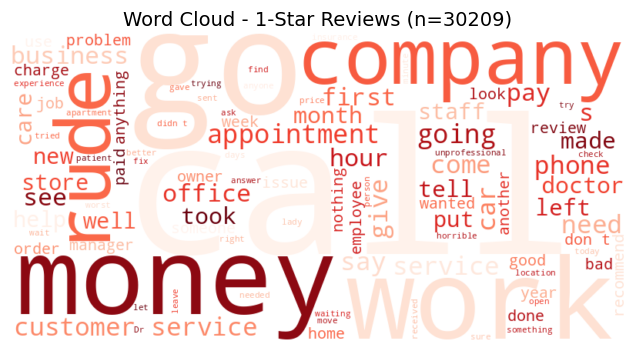

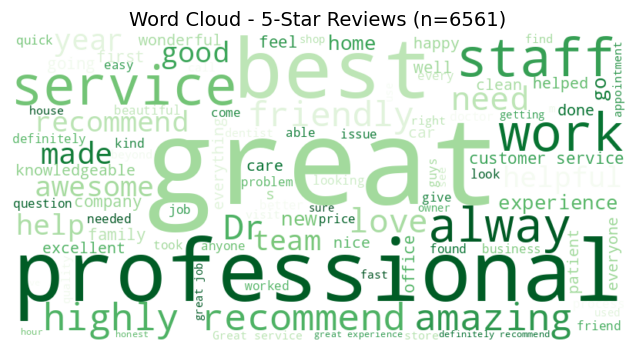

In [ ]:
# ==========================================
# WORD CLOUD VIUSALISATION
# ==========================================
def generate_specific_word_clouds(df, text_col='text', label_col='predictions'):
    print("\n--- Generating Word Clouds for 1-Star and 5-Star Reviews ---")
    target_classes = [0, 4]

    # Define and update using custom stop words
    custom_stopwords = set(STOPWORDS)
    custom_stopwords.update([
        'told', 'said', 'called', 'asked', 'time', 'one', 'day', 'even',
        'got', 'will', 'now', 'people', 'place', 'thing', 'went', 'came',
        'make', 'take', 'back', 'thank', 'thanks', 'guy', 'know', 'us',
        'want', 'still', 'never', 'much', 'really', 'way'
    ])

    for cls in target_classes:
        # Filter the dataframe for the specific class
        class_data = df[df[label_col] == cls]

        # Check if there are actually predictions for this class to avoid errors
        if class_data.empty:
            print(f"No predictions found for {cls}-star reviews.")
            continue

        class_text = " ".join(class_data[text_col].astype(str).tolist())

        # Skip if text is empty
        if len(class_text.strip()) == 0:
            continue

        # Use different color themes (Reds for 1-star, Greens for 5-star)
        cmap = 'Reds' if cls == 0 else 'Greens'

        wordcloud_cls = WordCloud(
            width=800,
            height=400,
            background_color='white',
            colormap=cmap,
            max_words=100,
            stopwords=custom_stopwords
        ).generate(class_text)

        plt.figure(figsize=(8, 4))
        plt.imshow(wordcloud_cls, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud - {cls+1}-Star Reviews (n={len(class_data)})', fontsize=14)
        plt.show()

# Run the updated word cloud function
generate_specific_word_clouds(df_relabelled)

## Interactive Topic Modelling with pyLDAvis

To move beyond simple word frequencies, this analysis employs Latent Dirichlet Allocation (LDA) visualized through pyLDAvis. This technique maps the deeper semantic structure of the ensemble-relabeled dataset, isolating distinct thematic clusters within the 1-star and 5-star review categories.

The visualization plots the relative distance and prevalence of these latent topics on a two-dimensional principal component axis, while simultaneously detailing the most salient terms associated with each specific cluster. This interactive exploration enables a comprehensive understanding of the nuanced contexts and specific operational drivers behind customer satisfaction and dissatisfaction, forming the structural basis for the final strategic insights.

In [ ]:
# Import Libraries
!pip install pyLDAvis

import os
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.lda_model
import warnings

### 5-Star Review

#### Baseline Evaluation

In [ ]:
# --- SUPPRESS WARNINGS ---
warnings.filterwarnings("ignore", category=DeprecationWarning)

# --- CONFIGURATION ---
csv_path = 'Relabelled Test Set.csv'

target_class = 4        # 5-Star Review

# --- LOAD DATA ---
print(f"Loading data from {csv_path}...")
if os.path.exists(csv_path):
    target_df = pd.read_csv(csv_path)

    # Filter for the specific predicted class
    filtered_df = target_df[target_df['predictions'] == target_class].copy()
    filtered_df['text'] = filtered_df['text'].astype(str).fillna("")
    print(f"Loaded {len(filtered_df)} samples for Predicted Reviews {target_class + 1}-Star.")
else:
    print(f"Error: File not found at {csv_path}")
    raise FileNotFoundError(f"Please check the path: {csv_path}")

print(f"\nStarting Topic Modeling for {target_class + 1}-Star Reviews...")

# --- VECTORIZATION ---
print("Vectorizing text...")
vect = CountVectorizer(max_features=10000, max_df=.15, stop_words='english')
X = vect.fit_transform(filtered_df['text'])

# --- FIT LDA MODEL ---
TOPICS_NUM = 10
print(f"Fitting LDA Model ({TOPICS_NUM} Topics)...")
lda = LatentDirichletAllocation(n_components=TOPICS_NUM, learning_method="batch",
                                max_iter=25, random_state=0)
document_topics = lda.fit_transform(X)

# Print Top Words for Each Topic (Text output)
print("\nTop Words per Topic:")
feature_names = np.array(vect.get_feature_names_out())
sorting = np.argsort(lda.components_, axis=1)[:, ::-1]

for i in range(TOPICS_NUM):
    top_words = feature_names[sorting[i, :TOPICS_NUM]]
    print(f"Topic {i}: {', '.join(top_words)}")

# --- VISUALISE WITH pyLDAvis ---
print("\nGenerating Interactive Visualization...")
pyLDAvis.enable_notebook()
vis = pyLDAvis.lda_model.prepare(lda, X, vect)

# --- SAVE AS HTML ---
save_path = f"lda{TOPICS_NUM}_visualization_class_{target_class}.html"

print(f"\nSaving interactive chart to {save_path}...")
pyLDAvis.save_html(vis, save_path)
print("Success!")

# Display
vis

Loading data from Relabelled Test Set.csv...
Loaded 6561 samples for Predicted Reviews 5-Star.

Starting Topic Modeling for 5-Star Reviews...
Vectorizing text...
Fitting LDA Model (10 Topics)...

Top Words per Topic:
Topic 0: dr, office, feel, care, dental, friendly, dentist, doctor, experience, years
Topic 1: place, love, amazing, friendly, super, clean, awesome, helpful, nice, hair
Topic 2: work, experience, kind, just, years, thank, body, ve, customer, look
Topic 3: job, work, company, did, new, came, price, guys, use, home
Topic 4: car, experience, did, shop, definitely, job, got, place, took, nice
Topic 5: helpful, friendly, customer, insurance, questions, excellent, definitely, extremely, knowledgeable, experience
Topic 6: home, process, experience, team, work, care, really, real, help, just
Topic 7: love, school, good, help, thank, better, like, pain, just, ve
Topic 8: thank, team, case, family, got, care, amazing, really, excellent, work
Topic 9: work, original, google, amazing

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.039202  0.062264       1        1  17.610604
3     -0.043315  0.147179       2        1  17.491011
4      0.075027  0.064133       3        1  11.991702
7     -0.030065 -0.040523       4        1  10.176192
6     -0.041123  0.008915       5        1   9.538507
1      0.254432 -0.043499       6        1   8.995886
5     -0.039668  0.105731       7        1   7.136830
8     -0.103916 -0.025345       8        1   6.903343
9     -0.008911 -0.188139       9        1   5.534915
2     -0.101663 -0.090716      10        1   4.621012, topic_info=          Term        Freq       Total Category  logprob  loglift
2074        dr  898.000000  898.000000  Default  30.0000  30.0000
7428     place  707.000000  707.000000  Default  29.0000  29.0000
5484      love  618.000000  618.000000  Default  28.0000  28.0000
3040  friendly  814.000000  814.000000  Default  27.0000  27.0000
6725    office  446.000000  446.000000  Default  26.0000  26.0000
...        ...         ...         ...      ...      ...      ...
6458      need   14.866960  281.620212  Topic10  -5.9452   0.1331
5303      like   15.014004  488.113377  Topic10  -5.9354  -0.4070
602    awesome   14.582813  441.529434  Topic10  -5.9645  -0.3358
7333     phone   13.356956  153.367186  Topic10  -6.0523   0.6338
1006  business   13.348729  259.091621  Topic10  -6.0529   0.1088

[760 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
10        1  0.244537     10
10        2  0.098855     10
10        3  0.504682     10
10        4  0.036420     10
10        8  0.031217     10
...     ...       ...    ...
9948      8  0.062808  years
9948      9  0.051388  years
9948     10  0.066614  years
9955      6  0.838733   yoga
9955      8  0.132432   yoga

[1865 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 4, 5, 8, 7, 2, 6, 9, 10, 3])

#### Refining Topic Separation for 5-Star Reviews

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# --- SUPPRESS WARNINGS ---
warnings.filterwarnings("ignore", category=DeprecationWarning)

# --- CONFIGURATION ---
csv_path = 'Relabelled Test Set.csv'
target_class = 4        # 5-Star Review

# --- LOAD DATA ---
print(f"Loading data from {csv_path}...")
if os.path.exists(csv_path):
    target_df = pd.read_csv(csv_path)

    # Filter for the specific predicted class
    filtered_df = target_df[target_df['predictions'] == target_class].copy()
    filtered_df['text'] = filtered_df['text'].astype(str).fillna("")
    print(f"Loaded {len(filtered_df)} samples for Predicted Reviews {target_class + 1}-Star.")
else:
    print(f"Error: File not found at {csv_path}")
    raise FileNotFoundError(f"Please check the path: {csv_path}")

print(f"\nStarting Topic Modeling for {target_class + 1}-Star Reviews...")

# --- CUSTOM STOP WORDS SETUP ---
custom_noise = [
    'good', 'great', 'excellent', 'amazing', 'awesome', 'best', 'love', 'nice',
    'always', 'really', 'very', 'much', 'go', 'get', 'got', 'came', 'went',
    'time', 'day', 'place', 'thank', 'thanks', 'just', 'will', 'even'
]
optimized_stop_words = list(ENGLISH_STOP_WORDS.union(custom_noise))

# --- VECTORIZATION ---
print("Vectorizing text...")
vect = CountVectorizer(
    max_features=10000,
    max_df=0.85,                  # Ignore ubiquitous terms appearing in >85% of documents
    min_df=10,                    # Ignore rare terms appearing in fewer than 10 documents
    stop_words=optimized_stop_words
)
X = vect.fit_transform(filtered_df['text'])

# --- FIT LDA MODEL ---
TOPICS_NUM = 10
print(f"Fitting LDA Model ({TOPICS_NUM} Topics)...")
lda = LatentDirichletAllocation(
    n_components=TOPICS_NUM,
    learning_method="batch",
    doc_topic_prior=0.1,          # Alpha: Forces documents to be composed of fewer topics
    topic_word_prior=0.1,        # Beta: Forces topics to be defined by a narrower set of words
    max_iter=25,
    random_state=0
)
document_topics = lda.fit_transform(X)

# Print Top Words for Each Topic (Text output)
print("\nTop Words per Topic:")
feature_names = np.array(vect.get_feature_names_out())
sorting = np.argsort(lda.components_, axis=1)[:, ::-1]

for i in range(TOPICS_NUM):
    # Retrieve top 10 words to match visual output expectations
    top_words = feature_names[sorting[i, :10]]
    print(f"Topic {i+1}: {', '.join(top_words)}")

# --- VISUALISE WITH pyLDAvis ---
print("\nGenerating Interactive Visualization...")
pyLDAvis.enable_notebook()
vis = pyLDAvis.lda_model.prepare(lda, X, vect)

# --- SAVE AS HTML ---
save_path = f"lda{TOPICS_NUM}_visualization_class_{target_class}_optimized.html"

print(f"\nSaving interactive chart to {save_path}...")
pyLDAvis.save_html(vis, save_path)
print("Success!")

# Display
vis

Loading data from Relabelled Test Set.csv...
Loaded 6561 samples for Predicted Reviews 5-Star.

Starting Topic Modeling for 5-Star Reviews...
Vectorizing text...
Fitting LDA Model (10 Topics)...

Top Words per Topic:
Topic 1: 10, life, fun, class, experience, loved, massage, like, better, training
Topic 2: questions, helped, like, help, sure, needed, answered, process, right, case
Topic 3: highly, recommend, recommended, professional, service, google, original, real, translated, knowledgeable
Topic 4: recommend, home, professional, highly, company, service, process, work, job, house
Topic 5: car, service, price, recommend, new, took, called, fixed, auto, repair
Topic 6: job, did, hair, definitely, clean, guys, recommend, salon, happy, professional
Topic 7: service, customer, ve, experience, family, people, friendly, store, shop, helpful
Topic 8: staff, friendly, helpful, professional, super, help, knowledgeable, son, office, wonderful
Topic 9: dr, staff, care, feel, office, recommend, 

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
8      0.150183 -0.032735       1        1  15.859930
3     -0.129783  0.010139       2        1  12.774622
1     -0.027082  0.158141       3        1  12.254733
4     -0.165739  0.070750       4        1  11.048891
6      0.051887 -0.052115       5        1  10.432695
9     -0.134264  0.049889       6        1   9.012745
5     -0.010887  0.065143       7        1   8.782649
7      0.187558 -0.129797       8        1   7.825827
0      0.183689  0.145134       9        1   6.812196
2     -0.105562 -0.284548      10        1   5.195713, topic_info=            Term         Freq        Total Category  logprob  loglift
738       highly  1058.000000  1058.000000  Default  30.0000  30.0000
1434     service  1533.000000  1533.000000  Default  29.0000  29.0000
1510       staff  1075.000000  1075.000000  Default  28.0000  28.0000
460           dr   927.000000   927.000000  Default  27.0000  27.0000
1300   recommend  1617.000000  1617.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
1436    services    41.186337   221.627700  Topic10  -4.8021   1.2744
281      clients    32.265019    94.003074  Topic10  -5.0462   1.8880
531   experience    38.182085   842.235237  Topic10  -4.8778  -0.1364
1145      people    34.048041   370.056319  Topic10  -4.9924   0.5715
1557       super    33.368968   354.985982  Topic10  -5.0126   0.5929

[657 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
0         1  0.097019     10
0         3  0.048509     10
0         4  0.150379     10
0         8  0.004851     10
0         9  0.698534     10
...     ...       ...    ...
1790      6  0.119274  years
1790      7  0.014457  years
1790      8  0.106624  years
1790      9  0.052408  years
1793      9  0.958282   yoga

[1417 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[9, 4, 2, 5, 7, 10, 6, 8, 1, 3])

### 1-Star Review

#### Baseline Evaluation

This subsection presents the initial LDA model for the 1-star reviews, serving as the foundational baseline for topic analysis. Generated using default hyperparameters and the full un-sampled dataset, this preliminary model provides a first-pass overview of 1-star review themes.

The primary purpose of this baseline is to evaluate the raw thematic structure. The resulting visualization highlights inherent challenges in the unstructured data, specifically the high degree of topic overlap and semantic clustering which directly justifies the need for the subsequent optimization, downsampling, and advanced filtering techniques.

In [ ]:
# --- SUPPRESS WARNINGS ---
warnings.filterwarnings("ignore", category=DeprecationWarning)

# --- CONFIGURATION ---
csv_path = 'Relabelled Test Set.csv'

target_class = 0        # 1-Star Review

# --- LOAD DATA ---
print(f"Loading data from {csv_path}...")
if os.path.exists(csv_path):
    target_df = pd.read_csv(csv_path)

    # Filter for the specific predicted class
    filtered_df = target_df[target_df['predictions'] == target_class].copy()
    filtered_df['text'] = filtered_df['text'].astype(str).fillna("")
    print(f"Loaded {len(filtered_df)} samples for Predicted Reviews {target_class + 1}-Star.")
else:
    print(f"Error: File not found at {csv_path}")
    raise FileNotFoundError(f"Please check the path: {csv_path}")

print(f"\nStarting Topic Modeling for {target_class + 1}-Star Reviews...")

# --- VECTORIZATION ---
print("Vectorizing text...")
vect = CountVectorizer(max_features=10000, max_df=.15, stop_words='english')
X = vect.fit_transform(filtered_df['text'])

# --- FIT LDA MODEL ---
TOPICS_NUM = 10
print(f"Fitting LDA Model ({TOPICS_NUM} Topics)...")
lda = LatentDirichletAllocation(n_components=TOPICS_NUM, learning_method="batch",
                                max_iter=25, random_state=0)
document_topics = lda.fit_transform(X)

# Print Top Words for Each Topic (Text output)
print("\nTop Words per Topic:")
feature_names = np.array(vect.get_feature_names_out())
sorting = np.argsort(lda.components_, axis=1)[:, ::-1]

for i in range(TOPICS_NUM):
    top_words = feature_names[sorting[i, :TOPICS_NUM]]
    print(f"Topic {i}: {', '.join(top_words)}")

# --- VISUALISE WITH pyLDAvis ---
print("\nGenerating Interactive Visualization...")
pyLDAvis.enable_notebook()
vis = pyLDAvis.lda_model.prepare(lda, X, vect)

# --- SAVE AS HTML ---
save_path = f"lda{TOPICS_NUM}_visualization_class_{target_class}.html"

print(f"\nSaving interactive chart to {save_path}...")
pyLDAvis.save_html(vis, save_path)
print("Success!")

# Display
vis

Loading data from Relabelled Test Set.csv...
Loaded 30209 samples for Predicted Reviews 1-Star.

Starting Topic Modeling for 1-Star Reviews...
Vectorizing text...
Fitting LDA Model (10 Topics)...

Top Words per Topic:
Topic 0: money, pay, company, account, paid, card, credit, bank, charge, insurance
Topic 1: rude, people, like, staff, school, help, lady, know, kids, person
Topic 2: called, phone, day, days, company, appointment, said, calls, answer, times
Topic 3: google, que, original, translated, la, el, las, en, es, para
Topic 4: car, said, price, took, fix, new, did, got, shop, work
Topic 5: said, store, asked, didn, did, went, truck, manager, wanted, location
Topic 6: doctor, office, dr, appointment, care, insurance, said, did, went, didn
Topic 7: customer, rude, worst, people, horrible, business, bad, experience, money, company
Topic 8: minutes, food, open, said, 30, hours, got, closed, hour, order
Topic 9: apartment, hair, management, rent, like, water, did, property, moved, liv

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
6      0.057697 -0.003125       1        1  13.637443
2      0.078932 -0.118186       2        1  12.773331
9      0.055659  0.020604       3        1  12.629909
5      0.071809 -0.020887       4        1  10.555910
0      0.045649 -0.057873       5        1  10.411163
7     -0.003083  0.211021       6        1  10.222372
1      0.006962  0.204009       7        1   9.363076
4      0.066174 -0.115089       8        1   9.231971
8      0.051133 -0.067555       9        1   8.814643
3     -0.430931 -0.052919      10        1   2.360182, topic_info=          Term         Freq        Total Category  logprob  loglift
1581       car  2991.000000  2991.000000  Default  30.0000  30.0000
7653      rude  4132.000000  4132.000000  Default  29.0000  29.0000
6533     phone  3914.000000  3914.000000  Default  28.0000  28.0000
2934    doctor  2141.000000  2141.000000  Default  27.0000  27.0000
1532    called  5388.000000  5388.000000  Default  26.0000  26.0000
...        ...          ...          ...      ...      ...      ...
6496      pero    97.442578    98.331532  Topic10  -5.4274   3.7373
3326      esta    88.978507    89.867464  Topic10  -5.5183   3.7365
6217  original   706.697843   910.918348  Topic10  -3.4461   3.4926
973        bad   202.902911  2942.500058  Topic10  -4.6939   1.0721
8306       son   117.453594   951.729616  Topic10  -5.2406   1.6542

[724 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
13        1  0.077045    10
13        2  0.150506    10
13        3  0.028668    10
13        4  0.038224    10
13        5  0.090184    10
...     ...       ...   ...
9989      4  0.015745  zero
9989      5  0.093160  zero
9989      6  0.606197  zero
9989      7  0.048548  zero
9989      8  0.035427  zero

[1963 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[7, 3, 10, 6, 1, 8, 2, 5, 9, 4])

#### Refining Topic Separation for 1-Star Reviews

The initial baseline LDA model for the 1-star reviews exhibited significant overlap, with latent themes appearing highly clustered or "crumbed" together in the multidimensional space. This indicated that generic, high-frequency complaints were blurring the boundaries between distinct operational issues.

To achieve clearer semantic separation, a two-pronged optimization approach is implemented:

1. **Aggressive Stop Word Filtering:** A more rigorous custom stop-word list is applied to eliminate persistent noise and non-descriptive conversational filler.

2. **Hyperparameter Tuning:** Key model parameters are adjusted to force sharper topic boundaries. This includes:
    * Fine-tuning term frequency thresholds (`max_df` and `min_df`) to exclude overly ubiquitous or extremely rare terms.

    * Adjustments on the Dirichlet prior parameters, specifically Aplha (`doc_topic_prior`) and Beta (`topic_word_prior`) to influence the distributions of topics within documents and words within topics. Ultimately yielding more isolated and interpretable clusters.

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# --- SUPPRESS WARNINGS ---
warnings.filterwarnings("ignore", category=DeprecationWarning)

# --- CONFIGURATION ---
csv_path = 'Relabelled Test Set.csv'

target_class = 0        # 1-Star Review

# --- LOAD DATA ---
print(f"Loading data from {csv_path}...")
if os.path.exists(csv_path):
    target_df = pd.read_csv(csv_path)

    # Filter for the specific predicted class
    filtered_df = target_df[target_df['predictions'] == target_class].copy()
    filtered_df['text'] = filtered_df['text'].astype(str).fillna("")
    print(f"Loaded {len(filtered_df)} samples for Predicted Reviews {target_class + 1}-Star.")
else:
    print(f"Error: File not found at {csv_path}")
    raise FileNotFoundError(f"Please check the path: {csv_path}")

print(f"\nStarting Topic Modeling for {target_class + 1}-Star Reviews...")

# --- INITIALISE STOPWORDS ---
custom_stop_words = [
    # General fillers
    'like', 'just', 'really', 'don', 'good', 'make', 'think', 'know', 'way', 'thing', 'lot', 'say',
    # Storytelling verbs (The "He said, She said" problem)
    'said', 'did', 'didn', 'went', 'got', 'asked', 'wanted', 'took', 'told', 'called', 'came',
    # Google Translate & Spanish artifacts
    'google', 'original', 'translated', 'translate', 'que', 'por', 'lo', 'la', 'el', 'las', 'en', 'es', 'para', 'una', 'los', 'con',
    # Generic Entities & Time (that don't add specific meaning)
    'company', 'business', 'people', 'person', 'guy', 'lady', 'day', 'days', 'times', 'today'
]

# Combine with standard English stop words
my_stop_words = list(text.ENGLISH_STOP_WORDS.union(custom_stop_words))

# --- Vectorize ---
print("Vectorizing text with Bigrams and stricter frequencies...")
vect = CountVectorizer(
    max_features=10000,
    max_df=0.08,           # Ignores words in >8% of docs.
    min_df=10,             # Ignores rare typos that appear in fewer than 10 docs.
    ngram_range=(1, 2),    # Uses both single words AND two-word phrases (Bigrams).
    stop_words=my_stop_words
)
X = vect.fit_transform(filtered_df['text'])

# --- Fit LDA Model ---
TOPICS_NUM = 10
print(f"Fitting LDA Model ({TOPICS_NUM} Topics)...")

lda = LatentDirichletAllocation(
    n_components=TOPICS_NUM,
    learning_method="batch",
    max_iter=25,
    random_state=0,
    doc_topic_prior=0.1,   # TWEAK (Alpha): Forces documents into fewer, sharper topics.
    topic_word_prior=0.1   # TWEAK (Beta): Forces topics to use distinct, non-overlapping words.
)

document_topics = lda.fit_transform(X)

print("\nTop Words per Topic:")
feature_names = np.array(vect.get_feature_names_out())
sorting = np.argsort(lda.components_, axis=1)[:, ::-1]
for i in range(TOPICS_NUM):
    top_words = feature_names[sorting[i, :10]]
    print(f"Topic {i}: {', '.join(top_words)}")

# --- VISUALISE WITH pyLDAvis ---
print("\nGenerating Interactive Visualization...")
pyLDAvis.enable_notebook()
vis = pyLDAvis.lda_model.prepare(lda, X, vect)

# --- SAVE AS HTML ---
save_path = f"lda{TOPICS_NUM}_visualization_class_{target_class}_refined.html"

print(f"\nSaving interactive chart to {save_path}...")
pyLDAvis.save_html(vis, save_path)
print("Success!")

# Display
vis

Loading data from Relabelled Test Set.csv...
Loaded 30209 samples for Predicted Reviews 1-Star.

Starting Topic Modeling for 1-Star Reviews...
Vectorizing text with Bigrams and stricter frequencies...
Fitting LDA Model (10 Topics)...

Top Words per Topic:
Topic 0: car, nails, vehicle, nail, shop, fix, truck, oil, cars, buy
Topic 1: management, apartment, rent, property, school, month, moved, unit, lease, pay
Topic 2: horrible, terrible, food, waste, recommend, experience, unprofessional, dont, stars, staff
Topic 3: hair, minutes, help, manager, ask, store, walked, ve, right, customers
Topic 4: water, home, dog, clean, door, left, house, broken, fix, cleaning
Topic 5: appointment, doctor, dr, wait, minutes, waiting, hour, hours, pain, care
Topic 6: staff, insurance, care, ve, help, family, review, reviews, need, does
Topic 7: store, pay, price, charge, charged, card, new, credit, paid, buy
Topic 8: open, closed, hours, bank, account, door, location, says, close, number
Topic 9: order, r

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
7     -0.017116 -0.060654       1        1  13.555968
5      0.061725  0.042543       2        1  13.104278
3     -0.003472  0.072469       3        1  12.989952
9      0.144947 -0.035682       4        1  11.632021
6      0.014881  0.127407       5        1  11.327128
1     -0.026552 -0.048209       6        1  10.487806
4     -0.097572 -0.112134       7        1   8.293682
2     -0.157481  0.250557       8        1   7.444435
0     -0.170402 -0.205059       9        1   5.745206
8      0.251044 -0.031238      10        1   5.419526, topic_info=             Term         Freq        Total Category  logprob  loglift
1393          car  3006.000000  3006.000000  Default  30.0000  30.0000
651   appointment  3225.000000  3225.000000  Default  29.0000  29.0000
4062     horrible  2526.000000  2526.000000  Default  28.0000  28.0000
2571       doctor  2135.000000  2135.000000  Default  27.0000  27.0000
5815         open  1394.000000  1394.000000  Default  26.0000  26.0000
...           ...          ...          ...      ...      ...      ...
2732      driving   153.505981   352.729440  Topic10  -5.7234   2.0832
2594         does   215.735410  1424.924381  Topic10  -5.3831   1.0273
5518         need   235.886936  2380.868187  Topic10  -5.2938   0.6033
4293  information   193.622107  1005.276970  Topic10  -5.4912   1.2681
19             10   211.192678  1673.232194  Topic10  -5.4044   0.8454

[716 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
0         1  0.648506          00
0         2  0.111571          00
0         4  0.049975          00
0         6  0.034866          00
0         9  0.060434          00
...     ...       ...         ...
9991      9  0.013150        zero
9997      1  0.017447  zero stars
9997      2  0.006979  zero stars
9997      4  0.115153  zero stars
9997      8  0.858416  zero stars

[2071 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[8, 6, 4, 10, 7, 2, 5, 3, 1, 9])

#### Strategic Downsampling for Topic Clarity

To further refine the topic modeling process, the 1-star review dataset is strategically downsampled from 30,209 to 10,000 observations. While large datasets benefit predictive machine learning, massive text volumes often degrade the interpretability of topic models. A smaller, representative sample is utilized to achieve three primary objectives:

* **Reduce Semantic Noise:** Minimizes the volume of generic complaints that obscure specific, actionable issues.

* **Enhance Topic Distinctiveness:** Compels the algorithm to cluster based on meaningful word co-occurrences rather than sheer frequency, resulting in sharper topic boundaries.

* **Improve Computational Efficiency:** Ensures the interactive pyLDAvis visualizations render smoothly and remain highly responsive.

This targeted downsampling ensures the final analysis highlights distinct operational failures rather than a single, dense cluster of generalized dissatisfaction.

In [ ]:
# --- LOAD DATA ---
csv_path = 'Relabelled Test Set.csv'
target_class = 0      # 1-Star Review

print(f"Loading data from {csv_path}...")
if os.path.exists(csv_path):
    target_df = pd.read_csv(csv_path)

    # Filter for the specific predicted class
    filtered_df = target_df[target_df['predictions'] == target_class].copy()
    filtered_df['text'] = filtered_df['text'].astype(str).fillna("")
    print(f"Originally loaded {len(filtered_df)} samples for {target_class + 1}-Star.")

    # --- RANDOM DOWNSAMPLING ---
    TARGET_SAMPLE_SIZE = 10000
    if len(filtered_df) > TARGET_SAMPLE_SIZE:
        print(f"Downsampling to {TARGET_SAMPLE_SIZE} reviews to sharpen topics...")
        filtered_df = filtered_df.sample(n=TARGET_SAMPLE_SIZE, random_state=42)

    print(f"Final working dataset: {len(filtered_df)} samples.")
else:
    print(f"Error: File not found at {csv_path}")
    raise FileNotFoundError(f"Please check the path: {csv_path}")

filtered_df.head()

Loading data from Relabelled Test Set.csv...
Originally loaded 30209 samples for 1-Star.
Downsampling to 10000 reviews to sharpen topics...
Final working dataset: 10000 samples.


,text,rating,predictions
48870,Glasses lasted 7 months with the only use bein...,1,0
49105,"If I could rate a 0, I would. Who consistently...",1,0
47200,I honestly liked working for them only cause I...,1,0
1081,Too many plumbing problems. Been here almost t...,2,0
5012,These guys just want your money! My boyfriend ...,1,0


In [ ]:
from sklearn.feature_extraction import text

# --- SUPPRESS WARNINGS ---
warnings.filterwarnings("ignore", category=DeprecationWarning)

# --- CONFIGURATION ---
target_class = 0        # 1-Star Review

print(f"\nStarting Topic Modeling for {target_class + 1}-Star Reviews...")

# --- INITIALISE STOPWORDS ---
custom_stop_words = [
    # General fillers
    'like', 'just', 'really', 'don', 'good', 'make', 'think', 'know', 'way', 'thing', 'lot', 'say',
    # Storytelling verbs (The "He said, She said" problem)
    'said', 'did', 'didn', 'went', 'got', 'asked', 'wanted', 'took', 'told', 'called', 'came',
    # Google Translate & Spanish artifacts
    'google', 'original', 'translated', 'translate', 'que', 'por', 'lo', 'la', 'el', 'las', 'en', 'es', 'para', 'una', 'los', 'con',
    # Generic Entities & Time (that don't add specific meaning)
    'company', 'business', 'people', 'person', 'guy', 'lady', 'day', 'days', 'times', 'today'
]

# Combine with standard English stop words
my_stop_words = list(text.ENGLISH_STOP_WORDS.union(custom_stop_words))

# --- Vectorize ---
print("Vectorizing text with Bigrams and stricter frequencies...")
vect = CountVectorizer(
    max_features=10000,
    max_df=0.08,           # TWEAK: Dropped from 0.15. Ignores words in >8% of docs.
    min_df=10,             # TWEAK: Ignores rare typos that appear in fewer than 10 docs.
    ngram_range=(1, 2),    # TWEAK: Uses both single words AND two-word phrases (Bigrams).
    stop_words=my_stop_words
)
X = vect.fit_transform(filtered_df['text'])

# --- Fit LDA Model ---
TOPICS_NUM = 10
print(f"Fitting LDA Model ({TOPICS_NUM} Topics)...")

lda = LatentDirichletAllocation(
    n_components=TOPICS_NUM,
    learning_method="batch",
    max_iter=25,
    random_state=0,
    doc_topic_prior=0.1,   # TWEAK (Alpha): Forces documents into fewer, sharper topics.
    topic_word_prior=0.1   # TWEAK (Beta): Forces topics to use distinct, non-overlapping words.
)

document_topics = lda.fit_transform(X)

print("\nTop Words per Topic:")
feature_names = np.array(vect.get_feature_names_out())
sorting = np.argsort(lda.components_, axis=1)[:, ::-1]
for i in range(TOPICS_NUM):
    top_words = feature_names[sorting[i, :10]]
    print(f"Topic {i}: {', '.join(top_words)}")

# --- VISUALISE WITH pyLDAvis ---
print("\nGenerating Interactive Visualization...")
pyLDAvis.enable_notebook()
vis = pyLDAvis.lda_model.prepare(lda, X, vect)

# --- SAVE AS HTML ---
save_path = f"lda{TOPICS_NUM}_visualization_class_{target_class}_refined_and_downsampled.html"

print(f"\nSaving interactive chart to {save_path}...")
pyLDAvis.save_html(vis, save_path)
print("Success!")

# Display
vis


Starting Topic Modeling for 1-Star Reviews...
Vectorizing text with Bigrams and stricter frequencies...
Fitting LDA Model (10 Topics)...

Top Words per Topic:
Topic 0: car, truck, price, vehicle, new, pay, shop, use, charged, buy
Topic 1: months, insurance, received, later, weeks, paid, pay, years, sent, tried
Topic 2: account, bank, number, store, location, manager, check, return, package, pay
Topic 3: apartment, management, rent, water, property, home, new, moved, live, unit
Topic 4: horrible, staff, unprofessional, care, extremely, insurance, terrible, manager, help, ve
Topic 5: away, dont, stay, card, stars, stay away, zero, order, owner, doing
Topic 6: hair, food, nails, school, cut, son, nail, old, left, salon
Topic 7: store, walked, review, wasn, employee, ask, owner, right, looking, door
Topic 8: recommend, waste, poor, job, waste time, answer, better, calls, post, quote
Topic 9: appointment, doctor, minutes, dr, hours, wait, waiting, hour, 30, patient

Generating Interactive 

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1     -0.047180 -0.086973       1        1  16.336321
9     -0.015950  0.046283       2        1  14.919239
7      0.040759  0.052666       3        1  11.343678
3     -0.132050  0.090262       4        1  10.458459
0     -0.213473 -0.031194       5        1   9.726886
4      0.209979  0.072986       6        1   8.161804
2     -0.037665 -0.196632       7        1   7.782597
6     -0.039718  0.186425       8        1   7.502757
8      0.102638 -0.072413       9        1   7.384294
5      0.132660 -0.061410      10        1   6.383965, topic_info=             Term         Freq        Total Category  logprob  loglift
649           car   999.000000   999.000000  Default  30.0000  30.0000
307   appointment  1022.000000  1022.000000  Default  29.0000  29.0000
1777     horrible   802.000000   802.000000  Default  28.0000  28.0000
3531        staff   925.000000   925.000000  Default  27.0000  27.0000
1161       doctor   665.000000   665.000000  Default  26.0000  26.0000
...           ...          ...          ...      ...      ...      ...
1279    employees    60.533735   343.274063  Topic10  -5.5937   1.0161
2398         need    65.257597   773.146248  Topic10  -5.5186   0.2793
3724         tell    63.615633   661.176712  Topic10  -5.5440   0.4102
3150      reviews    61.550021   452.579588  Topic10  -5.5771   0.7563
714       charged    60.614317   461.824087  Topic10  -5.5924   0.7207

[733 rows x 6 columns], token_table=      Topic      Freq           Term
term                                
0         1  0.158583             00
0         2  0.191621             00
0         4  0.006608             00
0         5  0.528610             00
0         7  0.049557             00
...     ...       ...            ...
4311      7  0.029113           zero
4311      9  0.080062           zero
4311     10  0.604102           zero
4312      3  0.950135  zero customer
4314     10  0.992123     zero stars

[1970 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 10, 8, 4, 1, 5, 3, 7, 9, 6])

# Saved Models, Datasets, and Visualisations

**Models:**
* Naive Bayes: https://drive.google.com/drive/folders/1xC862izuTcQIc4Gbef9ze2aWa0lWaEgh?usp=sharing

* LSTM: https://drive.google.com/drive/folders/1F71wMGwUbpqPxhyotWlEJsn-EfElBW-F?usp=sharing

* RoBERTa-Large: https://drive.google.com/drive/folders/1OlteW1BIozamUcs2QPRpuiaFEMz04WRZ?usp=sharing

* ELECTRA-Large: https://drive.google.com/drive/folders/1s7_RnjvQY9g4Xv25gtwmF4xa5YPudJ-C?usp=sharing

**Datasets**:
* https://drive.google.com/drive/folders/19_ePrUNbHPLyq41sEIpnKIvqM3nQYok3?usp=sharing

**Exported Visualisations:**
* https://drive.google.com/drive/folders/1Jr2v1X7cZFmsdg2nIGCA8dH9aV4fv9hR?usp=sharing